In [1]:
import os, math, random, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision.transforms import RandomErasing, RandomResizedCrop
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve
)
import rasterio

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
torch.backends.cudnn.benchmark = True

Using device: cuda


In [2]:
class CFG:
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/200x200/FINALCNNDATA_200')
    OUTPUTDIR     = Path('/kaggle/working')

    TRAINSITE     = ROOT / 'train' / 'site'
    TRAINNOSITE   = ROOT / 'train' / 'no_site'
    VALSITE       = ROOT / 'validation' / 'site'
    VALNOSITE     = ROOT / 'validation' / 'no_site'
    TESTSITE      = ROOT / 'test' / 'site'
    TESTNOSITE    = ROOT / 'test' / 'no_site'

    IMGSUFFIX     = '.tif'
    SATBANDS      = [0, 1, 2, 3]
    LIDARBANDS    = [4, 5, 6, 7, 8, 9, 10]
    INCHANNELS    = len(SATBANDS) + len(LIDARBANDS)

    NUMCLASSES    = 1
    IMGSIZE       = 200
    BATCHSIZE     = 32
    NUMEPOCHS     = 40
    BASELR        = 5e-5
    WEIGHTDECAY   = 0.1
    DROPOUT       = 0.6
    SEED          = 42
    NUMWORKERS    = 2
    USEAMP        = torch.cuda.is_available()

    PATIENCE      = 3
    MINDELTA      = 1e-3
    SCHED_FACTOR  = 0.5
    SCHED_PATIENCE = 2

    USEPOSWEIGHT  = False
    USEFOCALLOSS  = False
    FOCALGAMMA    = 2.0
    LABELSMOOTH   = 0.0

    HEADLRMULT    = 5.0
    LLRD          = 0.8
    FREEZEEPOCHS  = 8
    FREEZESTAGES  = 4

    STOCHDEPTH    = 0.3
    MIXUPPROB     = 0.0
    MIXUPALPHA    = 0.4
    ERASEPROB     = 0.10
    CROPSCALE     = (0.85, 1.0)
    SATNOISESTD   = 0.02
    LIDARNOISESTD = 0.05

    STEMNOISESTD  = 1e-4
    RGBDROPPROB   = 0.30
    LIDARDROPPROB = 0.15
    SAT_SCALE     = 10000.0
    IMAGENET_NORM = True

    LIDARNORM     = 'global'
    LIDARCLIP     = 8.0
    EVALTRAINEACHEPOCH = True

In [3]:
def setseed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setseed(CFG.SEED)
CFG.OUTPUTDIR.mkdir(parents=True, exist_ok=True)

In [4]:
def foldertodf(sitedir: Path, nositedir: Path) -> pd.DataFrame:
    rows = [{'filepath': str(f), 'label': l}
            for l, d in [(1, sitedir), (0, nositedir)]
            for f in sorted(d.glob(f'*{CFG.IMGSUFFIX}'))]
    return pd.DataFrame(rows)

print('Scanning dataset folders...')
traindf = foldertodf(CFG.TRAINSITE, CFG.TRAINNOSITE)
valdf   = foldertodf(CFG.VALSITE,   CFG.VALNOSITE)
testdf  = foldertodf(CFG.TESTSITE,  CFG.TESTNOSITE)

print(f"Train: {len(traindf)} | Val: {len(valdf)} | Test: {len(testdf)}")
print(f"Train class balance: {traindf['label'].value_counts().to_dict()}")

Scanning dataset folders...
Train: 3596 | Val: 1245 | Test: 878
Train class balance: {0: 2720, 1: 876}


In [5]:
def loadrawpatch(tifpath: str):
    with rasterio.open(tifpath) as src:
        img = src.read(masked=True).astype(np.float32).filled(0.0)
    sat = img[CFG.SATBANDS] / CFG.SAT_SCALE
    sat = np.clip(sat, 0.0, 1.0)
    return sat, img[CFG.LIDARBANDS]


def buildrawcache(df: pd.DataFrame, splitname: str):
    print(f"Caching {len(df)} {splitname} patches into RAM...")
    sats, lidars, labels = [], [], []
    for row in df.itertuples():
        s, l = loadrawpatch(row.filepath)
        sats.append(s); lidars.append(l); labels.append(float(row.label))
    return sats, lidars, labels


def computelidarstats(lidars):
    n = len(CFG.LIDARBANDS)
    total = np.zeros(n, np.float64)
    totalsq = np.zeros(n, np.float64)
    count = 0
    for l in lidars:
        ld = l.astype(np.float64)
        total   += ld.sum(axis=(1, 2))
        totalsq += (ld ** 2).sum(axis=(1, 2))
        count   += l.shape[1] * l.shape[2]
    mean = total / count
    var = np.maximum(totalsq / count - mean ** 2, 1e-12)
    return mean.astype(np.float32), np.sqrt(var).astype(np.float32)


def normalizelidarperpatch(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr, dtype=np.float32)
    for c, ch in enumerate(arr):
        mean, std = float(np.nanmean(ch)), float(np.nanstd(ch))
        out[c] = ch - mean if std < 1e-4 or np.isnan(std) else (ch - mean) / (std + 1e-6)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


def finalizecache(sats, lidars, labels, lmean, lstd):
    out = []
    for i in range(len(sats)):
        l = lidars[i]
        if CFG.LIDARNORM == 'global':
            ln = (l - lmean[:, None, None]) / (lstd[:, None, None] + 1e-6)
            ln = np.clip(ln, -CFG.LIDARCLIP, CFG.LIDARCLIP)
        else:
            ln = normalizelidarperpatch(l)
        ln = np.nan_to_num(ln, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        out.append((np.concatenate([sats[i], ln], axis=0), labels[i]))
        sats[i] = None; lidars[i] = None
    return out

In [6]:
class MultiModalDataset(Dataset):
    def __init__(self, cached, istrain: bool = True):
        self.cached = cached
        self.istrain = istrain
        self.randomerase = RandomErasing(p=CFG.ERASEPROB, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0)
        self.randomcrop = RandomResizedCrop(CFG.IMGSIZE, scale=CFG.CROPSCALE, ratio=(0.85, 1.18), antialias=True)
        self.rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.rgb_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.cached)

    def __getitem__(self, idx):
        img, label = self.cached[idx]
        t = torch.from_numpy(img).clone()
        nsat = len(CFG.SATBANDS)

        if CFG.IMAGENET_NORM and nsat >= 3:
            t[:3] = (t[:3] - self.rgb_mean) / self.rgb_std

        if self.istrain:
            t = self.randomcrop(t)
            if random.random() > 0.5: t = TF.hflip(t)
            if random.random() > 0.5: t = TF.vflip(t)
            k = random.choice([0, 1, 2, 3])
            if k: t = torch.rot90(t, k, dims=(1, 2))

            if random.random() > 0.5:
                t[:nsat] += torch.randn_like(t[:nsat]) * CFG.SATNOISESTD
                t[nsat:] += torch.randn_like(t[nsat:]) * CFG.LIDARNOISESTD

            t = self.randomerase(t)

            if random.random() < CFG.RGBDROPPROB:
                satmean = t[0:nsat].mean(dim=(1, 2), keepdim=True)
                t[0:nsat] = satmean.expand_as(t[0:nsat])
            if random.random() < CFG.LIDARDROPPROB:
                t[nsat:] = 0.0
        else:
            if t.shape[-1] != CFG.IMGSIZE or t.shape[-2] != CFG.IMGSIZE:
                t = TF.resize(t, [CFG.IMGSIZE, CFG.IMGSIZE],
                              interpolation=TF.InterpolationMode.BILINEAR, antialias=True)

        return t, torch.tensor(label, dtype=torch.float32)

In [7]:
trnsats, trnlidars, trnlabels_raw = buildrawcache(traindf, "Train")
LIDARMEAN, LIDARSTD = computelidarstats(trnlidars)
print(f"LiDAR channel means: {np.round(LIDARMEAN, 3)}")
print(f"LiDAR channel stds : {np.round(LIDARSTD, 3)}")

traincache = finalizecache(trnsats, trnlidars, trnlabels_raw, LIDARMEAN, LIDARSTD)
del trnsats, trnlidars; gc.collect()

vs, vl, vlab = buildrawcache(valdf, "Val")
valcache = finalizecache(vs, vl, vlab, LIDARMEAN, LIDARSTD)
del vs, vl; gc.collect()

ts, tl, tlab = buildrawcache(testdf, "Test")
testcache = finalizecache(ts, tl, tlab, LIDARMEAN, LIDARSTD)
del ts, tl; gc.collect()

Caching 3596 Train patches into RAM...
LiDAR channel means: [0.026 7.547 0.928 0.631 0.627 0.632 0.637]
LiDAR channel stds : [1.167 6.61  0.063 0.094 0.102 0.094 0.101]
Caching 1245 Val patches into RAM...
Caching 878 Test patches into RAM...


30

In [8]:
counts = traindf['label'].value_counts().to_dict()
sampleweights = [1.0 / counts[lbl] for lbl in traindf['label']]
sampler = WeightedRandomSampler(weights=sampleweights, num_samples=len(traindf), replacement=True)

trnloader      = DataLoader(MultiModalDataset(traincache, True),  batch_size=CFG.BATCHSIZE,
                            sampler=sampler, num_workers=CFG.NUMWORKERS, pin_memory=True, drop_last=True)
trnloader_eval = DataLoader(MultiModalDataset(traincache, False), batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
valloader      = DataLoader(MultiModalDataset(valcache, False),    batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
testloader     = DataLoader(MultiModalDataset(testcache, False),   batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

In [9]:
def createconvnextmodel(inchannels=11, numclasses=1, dropout=CFG.DROPOUT):
    model = models.convnext_tiny(
        weights=models.ConvNeXt_Tiny_Weights.DEFAULT,
        stochastic_depth_prob=CFG.STOCHDEPTH,
    )

    oldconv = model.features[0][0]
    oldinchannels  = oldconv.weight.shape[1]
    oldoutchannels = oldconv.out_channels

    newconv = nn.Conv2d(
        in_channels=inchannels,
        out_channels=oldoutchannels,
        kernel_size=oldconv.kernel_size,
        stride=oldconv.stride,
        padding=oldconv.padding,
        bias=oldconv.bias is not None,
    )

    with torch.no_grad():
        if inchannels == oldinchannels:
            newconv.weight[:] = oldconv.weight
        elif oldinchannels == 3 and inchannels > 3:
            newconv.weight[:, 0:3, :, :] = oldconv.weight
            meanweight = oldconv.weight.mean(dim=1)
            for c in range(3, inchannels):
                newconv.weight[:, c, :, :] = meanweight * 0.25
            newconv.weight[:, 3:inchannels, :, :] *= (oldinchannels / inchannels)
            newconv.weight[:, 3:inchannels, :, :] += torch.randn_like(
                newconv.weight[:, 3:inchannels, :, :]) * CFG.STEMNOISESTD
        else:
            nn.init.kaiming_normal_(newconv.weight, nonlinearity='relu')

        if oldconv.bias is not None:
            newconv.bias.copy_(oldconv.bias)

    model.features[0][0] = newconv
    infeatures = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Dropout(p=dropout),
        nn.Linear(infeatures, numclasses),
    )
    return model

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        ptcorrect = torch.where(targets >= 0.5, probs, 1 - probs)
        focalterm = (1 - ptcorrect).clamp(min=1e-6).pow(self.gamma)
        loss = focalterm * bce
        if self.pos_weight is not None:
            alphaweight = torch.where(targets >= 0.5, self.pos_weight, torch.ones_like(targets))
            loss = loss * alphaweight
        return loss.mean()

posweighttensor = None
if CFG.USEPOSWEIGHT:
    posweighttensor = torch.tensor([counts.get(0, 0) / max(counts.get(1, 1), 1)],
                                   dtype=torch.float32).to(DEVICE)

criterion = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=posweighttensor)
             if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=posweighttensor))

In [11]:
def ishead(name: str) -> bool:
    return name.startswith('features.0.0') or name.startswith('features.0.1') or name.startswith('classifier')

def stagedepth(name: str) -> int:
    if name.startswith('classifier'): return 8
    if name.startswith('features.'): return int(name.split('.')[1])
    return 0

def freezeearlystages(model, upto: int):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True
            continue
        if name.startswith('features.'):
            if int(name.split('.')[1]) < upto:
                p.requires_grad = False

def setbackbonefrozen(model, frozen: bool):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True
            continue
        if name.startswith('features.'):
            stage = int(name.split('.')[1])
            if stage < CFG.FREEZESTAGES:
                continue
        p.requires_grad = not frozen

def buildparamgroups(model, baselr, weightdecay, headlrmult, llrd):
    maxdepth = 8
    buckets = {}
    for name, p in model.named_parameters():
        lr = baselr * headlrmult if ishead(name) else baselr * (llrd ** (maxdepth - stagedepth(name)))
        wd = 0.0 if (p.ndim <= 1 or 'norm' in name.lower() or 'layer_scale' in name.lower()) else weightdecay
        buckets.setdefault((round(lr, 12), wd), []).append((name, p))

    groups = []
    for (lr, wd), items in sorted(buckets.items()):
        groups.append({'params': [p for _, p in items], 'lr': lr, 'weight_decay': wd})
    return groups

In [12]:
model = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
freezeearlystages(model, CFG.FREEZESTAGES)
setbackbonefrozen(model, frozen=True)

optimizer = optim.AdamW(buildparamgroups(model, CFG.BASELR, CFG.WEIGHTDECAY, CFG.HEADLRMULT, CFG.LLRD))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=CFG.SCHED_FACTOR,
                                                 patience=CFG.SCHED_PATIENCE, min_lr=1e-6)
scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)
backbonefrozen = True

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 176MB/s]


In [13]:
def computemetrics(ytrue, ypred):
    auc   = roc_auc_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    prauc = average_precision_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    binpreds = [1 if p >= 0.5 else 0 for p in ypred]
    return (auc, prauc,
            precision_score(ytrue, binpreds, zero_division=0),
            recall_score(ytrue, binpreds, zero_division=0),
            f1_score(ytrue, binpreds, zero_division=0),
            accuracy_score(ytrue, binpreds))


def trainepoch(model, loader, optimizer, scaler):
    model.train()
    totalloss, seen = 0.0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        target = (labels * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH
                  if CFG.LABELSMOOTH > 0 else labels)

        if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
            lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
            perm = torch.randperm(inputs.size(0), device=DEVICE)
            inputs = lam * inputs + (1 - lam) * inputs[perm]
            target = lam * target + (1 - lam) * target[perm]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, target)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
    return totalloss / max(seen, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    totalloss, seen, alllabels, allpreds = 0.0, 0, [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, labels)
        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
        allpreds.extend(np.nan_to_num(torch.sigmoid(logits).float().cpu().numpy(), nan=0.5))
        alllabels.extend(labels.cpu().numpy())
    return (totalloss / max(seen, 1), *computemetrics(alllabels, allpreds), alllabels, allpreds)

In [14]:
bestvalauc = 0.0
epochsnoimprove = 0
ckptpath = CFG.OUTPUTDIR / 'convnext_tiny_multimodal_best.pth'

history = {'epoch': [], 'trn_loss': [], 'val_loss': [],
           'trn_roc_auc': [], 'val_roc_auc': [],
           'trn_pr_auc': [], 'val_pr_auc': [],
           'trn_f1': [], 'val_f1': []}

print(f'\n{"="*78}\n  ConvNeXt-Tiny | 11-channel multimodal | max {CFG.NUMEPOCHS} epochs, patience {CFG.PATIENCE}\n{"="*78}')

for epoch in range(1, CFG.NUMEPOCHS + 1):
    if backbonefrozen and epoch > CFG.FREEZEEPOCHS:
        setbackbonefrozen(model, frozen=False)
        backbonefrozen = False
        epochsnoimprove = 0
        print(f'  -> Unfroze backbone at epoch {epoch}')

    trnloss = trainepoch(model, trnloader, optimizer, scaler)
    valloss, valauc, valprauc, valprec, valrec, valf1, valacc, _, _ = evaluate(model, valloader)

    if not backbonefrozen:
        scheduler.step(valauc)

    if CFG.EVALTRAINEACHEPOCH:
        ctrnloss, trnauc, trnprauc, _, _, trnf1, _, _, _ = evaluate(model, trnloader_eval)
    else:
        ctrnloss, trnauc, trnprauc, trnf1 = trnloss, 0.0, 0.0, 0.0

    history['epoch'].append(epoch)
    history['trn_loss'].append(ctrnloss)
    history['val_loss'].append(valloss)
    history['trn_roc_auc'].append(trnauc)
    history['val_roc_auc'].append(valauc)
    history['trn_pr_auc'].append(trnprauc)
    history['val_pr_auc'].append(valprauc)
    history['trn_f1'].append(trnf1)
    history['val_f1'].append(valf1)

    saved = ''
    if valauc > bestvalauc + CFG.MINDELTA:
        bestvalauc = valauc
        epochsnoimprove = 0
        torch.save(model.state_dict(), ckptpath)
        saved = '  ✓ saved'
    else:
        if not backbonefrozen:
            epochsnoimprove += 1

    headlr = max(g['lr'] for g in optimizer.param_groups)
    print(f'Ep {epoch:02d}/{CFG.NUMEPOCHS} | head LR: {headlr:.2e} | '
          f'clean AUC gap: {trnauc - valauc:+.4f} | patience: {epochsnoimprove}/{CFG.PATIENCE}{saved}')
    print(f'  Train (aug)   -> Loss: {trnloss:.4f}')
    print(f'  Train (clean) -> Loss: {ctrnloss:.4f} | ROC-AUC: {trnauc:.4f} | PR-AUC: {trnprauc:.4f} | F1: {trnf1:.4f}')
    print(f'  Val           -> Loss: {valloss:.4f} | ROC-AUC: {valauc:.4f} | PR-AUC: {valprauc:.4f} | F1: {valf1:.4f}')

    if not backbonefrozen and epochsnoimprove >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}: val ROC-AUC flat for {CFG.PATIENCE} epochs.')
        break


  ConvNeXt-Tiny | 11-channel multimodal | max 40 epochs, patience 3
Ep 01/40 | head LR: 2.50e-04 | clean AUC gap: -0.0214 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.7125
  Train (clean) -> Loss: 0.6690 | ROC-AUC: 0.5855 | PR-AUC: 0.3106 | F1: 0.3652
  Val           -> Loss: 0.6626 | ROC-AUC: 0.6069 | PR-AUC: 0.3428 | F1: 0.3599
Ep 02/40 | head LR: 2.50e-04 | clean AUC gap: -0.0350 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6992
  Train (clean) -> Loss: 0.6484 | ROC-AUC: 0.5881 | PR-AUC: 0.3158 | F1: 0.2961
  Val           -> Loss: 0.6410 | ROC-AUC: 0.6231 | PR-AUC: 0.3524 | F1: 0.2642
Ep 03/40 | head LR: 2.50e-04 | clean AUC gap: -0.0243 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6897
  Train (clean) -> Loss: 0.6788 | ROC-AUC: 0.6303 | PR-AUC: 0.3465 | F1: 0.4159
  Val           -> Loss: 0.6618 | ROC-AUC: 0.6546 | PR-AUC: 0.3871 | F1: 0.4587
Ep 04/40 | head LR: 2.50e-04 | clean AUC gap: -0.0263 | patience: 0/3
  Train (aug)   -> Loss: 0.6921
  Train (clean) 

In [15]:
if ckptpath.exists() and bestvalauc > 0.0:
    model.load_state_dict(torch.load(ckptpath, map_location=DEVICE, weights_only=True))
    model.eval()

    _, _, _, _, _, _, _, trnlabels, trnpreds  = evaluate(model, trnloader_eval)
    _, _, _, _, _, _, _, vallabels, valpreds  = evaluate(model, valloader)
    _, tstauc, tstprauc, _, _, _, _, testlabels, testpreds = evaluate(model, testloader)

    valprauc_best = average_precision_score(vallabels, valpreds)
    valprecisions, valrecalls, valthresholds = precision_recall_curve(vallabels, valpreds)
    f1_scores = 2 * (valprecisions[:-1] * valrecalls[:-1]) / (valprecisions[:-1] + valrecalls[:-1] + 1e-8)
    bestthresh = float(valthresholds[np.argmax(f1_scores)])

    testpredsnp, testlabelsnp = np.array(testpreds), np.array(testlabels)
    bindefault = (testpredsnp >= 0.5).astype(int)
    binopt     = (testpredsnp >= bestthresh).astype(int)

    print("\n" + "=" * 68 + "\n      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)\n" + "=" * 68)
    print(f"Threshold-free   -> ROC-AUC: {tstauc:.4f} | PR-AUC: {tstprauc:.4f}")
    print(f"Optimal threshold calibrated on val: {bestthresh:.4f}")

    for tag, binp in [("Default (0.50)", bindefault), (f"Calibrated ({bestthresh:.4f})", binopt)]:
        print(f"\nTest @ {tag}:")
        print(f"  • Precision : {precision_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Recall    : {recall_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • F1-Score  : {f1_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Accuracy  : {accuracy_score(testlabelsnp, binp):.4f}")
    print("=" * 68)


      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)
Threshold-free   -> ROC-AUC: 0.7746 | PR-AUC: 0.6270
Optimal threshold calibrated on val: 0.5850

Test @ Default (0.50):
  • Precision : 0.4650
  • Recall    : 0.6460
  • F1-Score  : 0.5407
  • Accuracy  : 0.7175

Test @ Calibrated (0.5850):
  • Precision : 0.5556
  • Recall    : 0.5088
  • F1-Score  : 0.5312
  • Accuracy  : 0.7688


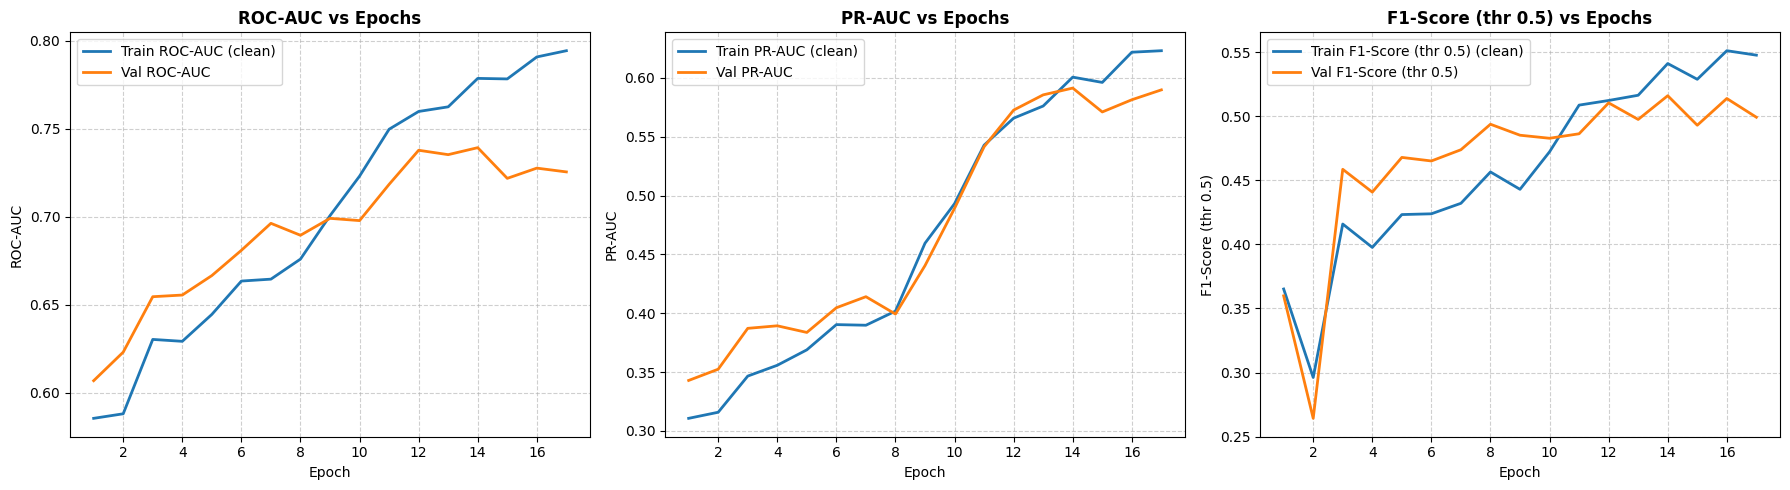

In [16]:
epochs = history['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (trnkey, valkey, name) in zip(axes, [
    ('trn_roc_auc', 'val_roc_auc', 'ROC-AUC'),
    ('trn_pr_auc',  'val_pr_auc',  'PR-AUC'),
    ('trn_f1',      'val_f1',      'F1-Score (thr 0.5)'),
]):
    ax.plot(epochs, history[trnkey], label=f'Train {name} (clean)', color='tab:blue', lw=2)
    ax.plot(epochs, history[valkey], label=f'Val {name}', color='tab:orange', lw=2)
    ax.set_title(f'{name} vs Epochs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(name)
    ax.grid(True, linestyle='--', alpha=0.6); ax.legend()
plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'metrics_progression.png', dpi=300)
plt.show()

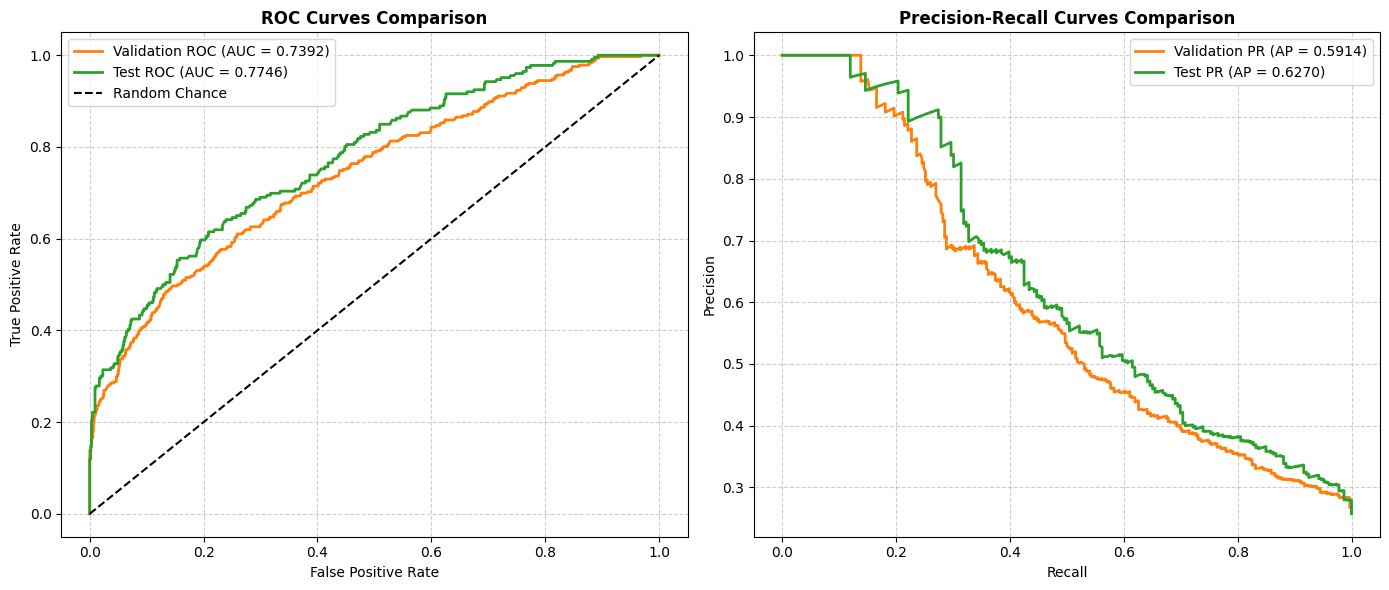

In [17]:
val_fpr, val_tpr, _ = roc_curve(vallabels, valpreds)
tst_fpr, tst_tpr, _ = roc_curve(testlabels, testpreds)
val_prec_c, val_rec_c, _ = precision_recall_curve(vallabels, valpreds)
tst_prec_c, tst_rec_c, _ = precision_recall_curve(testlabels, testpreds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(val_fpr, val_tpr, label=f'Validation ROC (AUC = {bestvalauc:.4f})', color='tab:orange', lw=2)
axes[0].plot(tst_fpr, tst_tpr, label=f'Test ROC (AUC = {tstauc:.4f})', color='tab:green', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[0].set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].grid(True, linestyle='--', alpha=0.6); axes[0].legend()

axes[1].plot(val_rec_c, val_prec_c, label=f'Validation PR (AP = {valprauc_best:.4f})', color='tab:orange', lw=2)
axes[1].plot(tst_rec_c, tst_prec_c, label=f'Test PR (AP = {tstprauc:.4f})', color='tab:green', lw=2)
axes[1].set_title('Precision-Recall Curves Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].grid(True, linestyle='--', alpha=0.6); axes[1].legend()

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'roc_pr_curves_comparison.png', dpi=300)
plt.show()

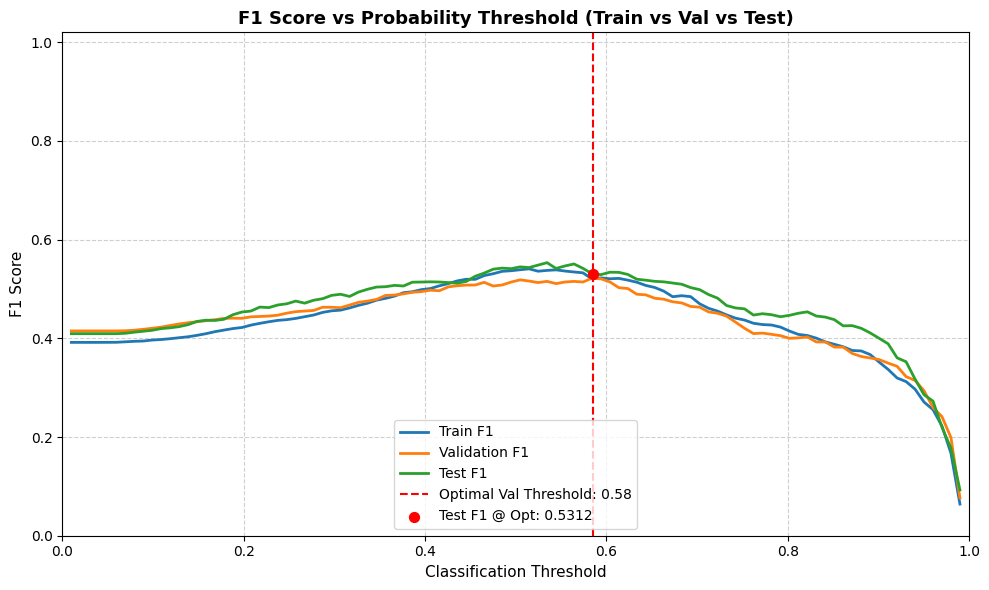

In [18]:
thresh_range = np.linspace(0.01, 0.99, 100)
trnpredsnp, valpredsnp = np.array(trnpreds), np.array(valpreds)
trn_f1_curve = [f1_score(trnlabels,  (trnpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
val_f1_curve = [f1_score(vallabels,  (valpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
tst_f1_curve = [f1_score(testlabels, (testpredsnp >= t).astype(int), zero_division=0) for t in thresh_range]

plt.figure(figsize=(10, 6))
plt.plot(thresh_range, trn_f1_curve, label='Train F1', color='tab:blue', lw=2)
plt.plot(thresh_range, val_f1_curve, label='Validation F1', color='tab:orange', lw=2)
plt.plot(thresh_range, tst_f1_curve, label='Test F1', color='tab:green', lw=2)
plt.axvline(x=bestthresh, color='red', linestyle='--', lw=1.5,
            label=f'Optimal Val Threshold: {bestthresh:.2f}')
test_f1_at_opt = f1_score(testlabelsnp, binopt, zero_division=0)
plt.scatter([bestthresh], [test_f1_at_opt], color='red', s=50, zorder=5,
            label=f'Test F1 @ Opt: {test_f1_at_opt:.4f}')
plt.title('F1 Score vs Probability Threshold (Train vs Val vs Test)', fontsize=13, fontweight='bold')
plt.xlabel('Classification Threshold', fontsize=11); plt.ylabel('F1 Score', fontsize=11)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.02])
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(loc='lower center', fontsize=10)
plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / '3in1_f1_threshold_curve.png', dpi=300)
plt.show()

gc.collect()
torch.cuda.empty_cache()


  PERMUTATION TEST (H0: predictions independent of labels)
Permutations: 2000
Test class balance: 0.2574 positive (226/878)

Metric       Observed    Null mean     Null std    Z-score      p-value
----------------------------------------------------------------------
PR-AUC         0.6270       0.2625       0.0155     23.543     0.000500
ROC-AUC        0.7746       0.4995       0.0228     12.046     0.000500

  -> PR-AUC significantly better than chance (p < 0.001).
  -> ROC-AUC significantly better than chance (p < 0.001).


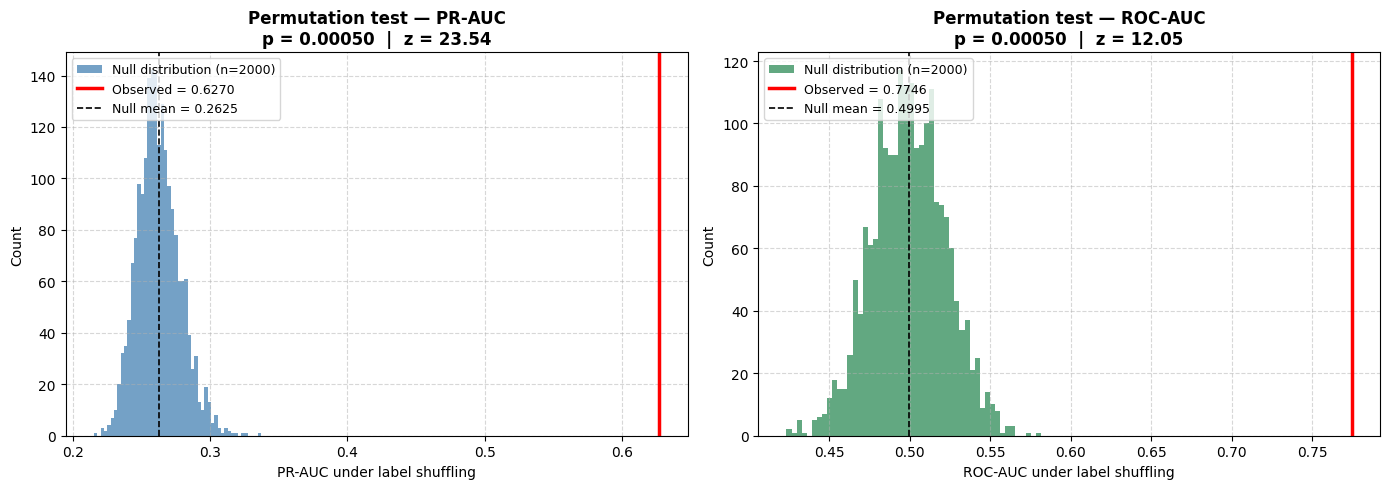

Saved: permutation_null_distributions.npz


In [19]:
# ==========================================
# PERMUTATION TEST — Is the model better than chance?
# ==========================================
# H0: predictions are independent of labels.
# Shuffle test labels N times, recompute metric, compare.
# p-value = fraction of null metrics >= observed.

print('\n' + '=' * 68)
print('  PERMUTATION TEST (H0: predictions independent of labels)')
print('=' * 68)

N_PERM = 2000
rng = np.random.default_rng(CFG.SEED)

testpredsnp  = np.asarray(testpreds,  dtype=np.float64)
testlabelsnp = np.asarray(testlabels, dtype=np.int64)

obs_pr  = average_precision_score(testlabelsnp, testpredsnp)
obs_roc = roc_auc_score(testlabelsnp, testpredsnp)

null_pr  = np.empty(N_PERM, dtype=np.float64)
null_roc = np.empty(N_PERM, dtype=np.float64)

for i in range(N_PERM):
    shuf = rng.permutation(testlabelsnp)
    if len(np.unique(shuf)) < 2:
        null_pr[i], null_roc[i] = 0.0, 0.5
        continue
    null_pr[i]  = average_precision_score(shuf, testpredsnp)
    null_roc[i] = roc_auc_score(shuf, testpredsnp)

# +1 correction so p is never exactly zero
p_pr  = (np.sum(null_pr  >= obs_pr)  + 1) / (N_PERM + 1)
p_roc = (np.sum(null_roc >= obs_roc) + 1) / (N_PERM + 1)

z_pr  = (obs_pr  - null_pr.mean())  / (null_pr.std()  + 1e-12)
z_roc = (obs_roc - null_roc.mean()) / (null_roc.std() + 1e-12)

print(f'Permutations: {N_PERM}')
print(f'Test class balance: {testlabelsnp.mean():.4f} positive '
      f'({testlabelsnp.sum()}/{len(testlabelsnp)})')
print()
print(f'{"Metric":<10} {"Observed":>10} {"Null mean":>12} {"Null std":>12} '
      f'{"Z-score":>10} {"p-value":>12}')
print('-' * 70)
print(f'{"PR-AUC":<10} {obs_pr:>10.4f} {null_pr.mean():>12.4f} '
      f'{null_pr.std():>12.4f} {z_pr:>10.3f} {p_pr:>12.6f}')
print(f'{"ROC-AUC":<10} {obs_roc:>10.4f} {null_roc.mean():>12.4f} '
      f'{null_roc.std():>12.4f} {z_roc:>10.3f} {p_roc:>12.6f}')
print()

if p_pr < 0.001:
    print('  -> PR-AUC significantly better than chance (p < 0.001).')
elif p_pr < 0.05:
    print('  -> PR-AUC significantly better than chance (p < 0.05).')
else:
    print('  -> PR-AUC NOT significant at p < 0.05.')

if p_roc < 0.001:
    print('  -> ROC-AUC significantly better than chance (p < 0.001).')
elif p_roc < 0.05:
    print('  -> ROC-AUC significantly better than chance (p < 0.05).')
else:
    print('  -> ROC-AUC NOT significant at p < 0.05.')

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(null_pr, bins=50, color='steelblue', alpha=0.75,
        label=f'Null distribution (n={N_PERM})')
ax.axvline(obs_pr, color='red', lw=2.5, label=f'Observed = {obs_pr:.4f}')
ax.axvline(null_pr.mean(), color='black', lw=1.2, ls='--',
           label=f'Null mean = {null_pr.mean():.4f}')
ax.set_title(f'Permutation test — PR-AUC\np = {p_pr:.5f}  |  z = {z_pr:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PR-AUC under label shuffling')
ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

ax = axes[1]
ax.hist(null_roc, bins=50, color='seagreen', alpha=0.75,
        label=f'Null distribution (n={N_PERM})')
ax.axvline(obs_roc, color='red', lw=2.5, label=f'Observed = {obs_roc:.4f}')
ax.axvline(null_roc.mean(), color='black', lw=1.2, ls='--',
           label=f'Null mean = {null_roc.mean():.4f}')
ax.set_title(f'Permutation test — ROC-AUC\np = {p_roc:.5f}  |  z = {z_roc:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('ROC-AUC under label shuffling')
ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'permutation_test.png', dpi=300)
plt.show()

np.savez(CFG.OUTPUTDIR / 'permutation_null_distributions.npz',
         null_pr=null_pr, null_roc=null_roc,
         obs_pr=obs_pr, obs_roc=obs_roc,
         p_pr=p_pr, p_roc=p_roc, n_perm=N_PERM)
print('Saved: permutation_null_distributions.npz')
print('=' * 68)


  BOOTSTRAP 95% CONFIDENCE INTERVALS (n=2000)
Metric          Point   Median               95% CI
----------------------------------------------------
ROC-AUC        0.7746   0.7750    [0.7388 – 0.8084]
PR-AUC         0.6270   0.6293    [0.5671 – 0.6844]
F1                  -   0.5310    [0.4742 – 0.5877]
Precision           -   0.5550    [0.4878 – 0.6230]
Recall              -   0.5088    [0.4444 – 0.5742]


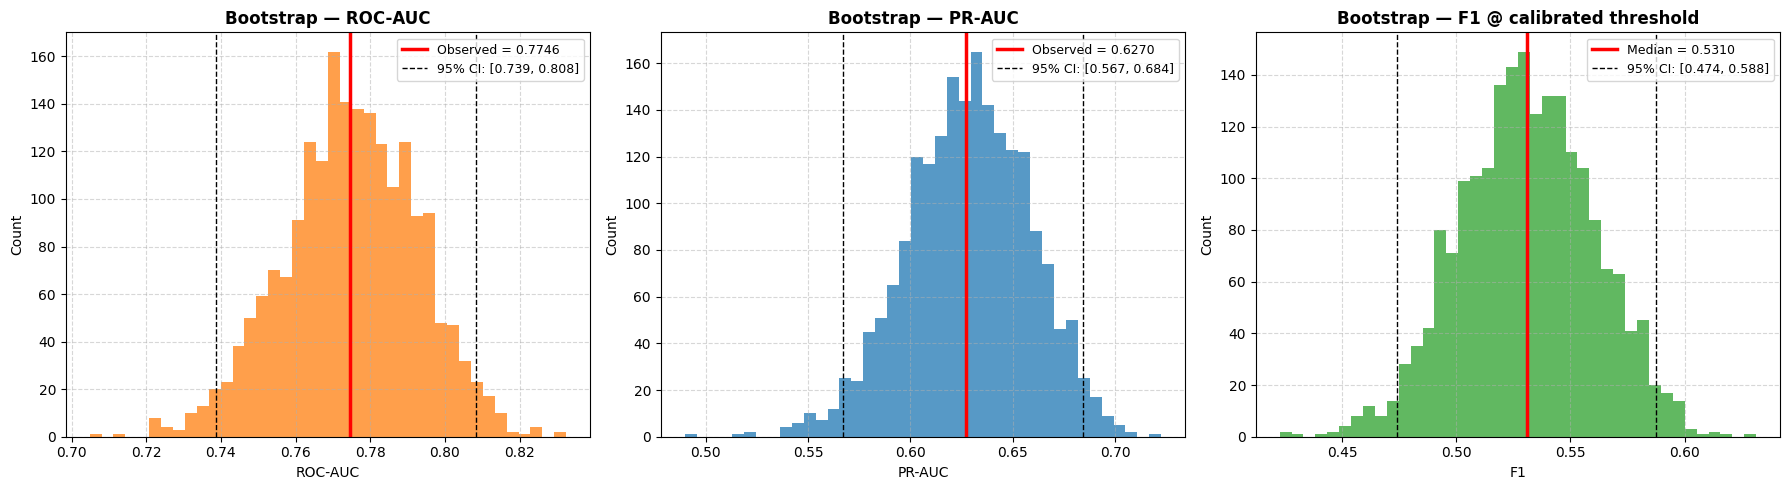

Saved: bootstrap_distributions.npz


In [20]:
# ==========================================
# BOOTSTRAP 95% CONFIDENCE INTERVALS
# ==========================================
# Resample the test set N times with replacement.
# Compute metric on each resample. Report the 2.5 / 50 / 97.5 quantiles.

def bootstrap_ci(y_true, y_pred, metric_fn, n=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_samples = len(y_true)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        yt = y_true[idx]
        yp = y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    scores = np.array(scores)
    return (np.quantile(scores, alpha / 2),
            np.quantile(scores, 0.5),
            np.quantile(scores, 1 - alpha / 2),
            scores)

print('\n' + '=' * 68)
print('  BOOTSTRAP 95% CONFIDENCE INTERVALS (n=2000)')
print('=' * 68)

# --- Threshold-free metrics ---
lo_pr,  med_pr,  hi_pr,  pr_scores  = bootstrap_ci(testlabelsnp, testpredsnp, average_precision_score)
lo_roc, med_roc, hi_roc, roc_scores = bootstrap_ci(testlabelsnp, testpredsnp, roc_auc_score)

# --- F1 at calibrated threshold ---
def f1_at_thr(yt, yp):
    return f1_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

lo_f1, med_f1, hi_f1, f1_scores = bootstrap_ci(testlabelsnp, testpredsnp, f1_at_thr)

# --- Precision and Recall at calibrated threshold ---
def prec_at_thr(yt, yp):
    return precision_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

def rec_at_thr(yt, yp):
    return recall_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

lo_prec, med_prec, hi_prec, _ = bootstrap_ci(testlabelsnp, testpredsnp, prec_at_thr)
lo_rec,  med_rec,  hi_rec,  _ = bootstrap_ci(testlabelsnp, testpredsnp, rec_at_thr)

print(f'{"Metric":<12} {"Point":>8} {"Median":>8} {"95% CI":>20}')
print('-' * 52)
print(f'{"ROC-AUC":<12} {obs_roc:>8.4f} {med_roc:>8.4f} '
      f'   [{lo_roc:.4f} – {hi_roc:.4f}]')
print(f'{"PR-AUC":<12} {obs_pr:>8.4f} {med_pr:>8.4f} '
      f'   [{lo_pr:.4f} – {hi_pr:.4f}]')
print(f'{"F1":<12} {"-":>8} {med_f1:>8.4f} '
      f'   [{lo_f1:.4f} – {hi_f1:.4f}]')
print(f'{"Precision":<12} {"-":>8} {med_prec:>8.4f} '
      f'   [{lo_prec:.4f} – {hi_prec:.4f}]')
print(f'{"Recall":<12} {"-":>8} {med_rec:>8.4f} '
      f'   [{lo_rec:.4f} – {hi_rec:.4f}]')
print('=' * 68)

# ---------- Plots ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(roc_scores, bins=40, color='tab:orange', alpha=0.75)
ax.axvline(obs_roc, color='red', lw=2.5, label=f'Observed = {obs_roc:.4f}')
ax.axvline(lo_roc, color='black', lw=1, ls='--', label=f'95% CI: [{lo_roc:.3f}, {hi_roc:.3f}]')
ax.axvline(hi_roc, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — ROC-AUC', fontweight='bold')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

ax = axes[1]
ax.hist(pr_scores, bins=40, color='tab:blue', alpha=0.75)
ax.axvline(obs_pr, color='red', lw=2.5, label=f'Observed = {obs_pr:.4f}')
ax.axvline(lo_pr, color='black', lw=1, ls='--', label=f'95% CI: [{lo_pr:.3f}, {hi_pr:.3f}]')
ax.axvline(hi_pr, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — PR-AUC', fontweight='bold')
ax.set_xlabel('PR-AUC'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

ax = axes[2]
ax.hist(f1_scores, bins=40, color='tab:green', alpha=0.75)
ax.axvline(med_f1, color='red', lw=2.5, label=f'Median = {med_f1:.4f}')
ax.axvline(lo_f1, color='black', lw=1, ls='--', label=f'95% CI: [{lo_f1:.3f}, {hi_f1:.3f}]')
ax.axvline(hi_f1, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — F1 @ calibrated threshold', fontweight='bold')
ax.set_xlabel('F1'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'bootstrap_ci.png', dpi=300)
plt.show()

# Save arrays for the paper
np.savez(CFG.OUTPUTDIR / 'bootstrap_distributions.npz',
         pr_scores=pr_scores, roc_scores=roc_scores, f1_scores=f1_scores,
         obs_pr=obs_pr, obs_roc=obs_roc)
print('Saved: bootstrap_distributions.npz')

In [21]:
def train_one_run(df_train, df_val, df_test, run_seed=42, run_tag='lc'):
    """Full training run from scratch. Returns dict of metrics."""
    setseed(run_seed)

    # ---------- Cache ----------
    s_tr, l_tr, y_tr = buildrawcache(df_train, f'{run_tag}-tr')
    tr_cache = finalizecache(s_tr, l_tr, y_tr, LIDARMEAN, LIDARSTD)
    del s_tr, l_tr; gc.collect()

    s_v, l_v, y_v = buildrawcache(df_val, f'{run_tag}-va')
    va_cache = finalizecache(s_v, l_v, y_v, LIDARMEAN, LIDARSTD)
    del s_v, l_v; gc.collect()

    s_t, l_t, y_t = buildrawcache(df_test, f'{run_tag}-te')
    te_cache = finalizecache(s_t, l_t, y_t, LIDARMEAN, LIDARSTD)
    del s_t, l_t; gc.collect()

    # ---------- Sampler ----------
    cnt = df_train['label'].value_counts().to_dict()
    if cnt.get(0, 0) == 0 or cnt.get(1, 0) == 0:
        print(f'  [{run_tag}] SKIP — degenerate subset '
              f'(pos={cnt.get(1,0)}, neg={cnt.get(0,0)})')
        return {'run_tag': run_tag, 'error': 'degenerate',
                'n_train': len(df_train), 'frac': None}

    weights = [1.0 / cnt[lbl] for lbl in df_train['label']]
    smp = WeightedRandomSampler(weights=weights,
                                num_samples=len(df_train),
                                replacement=True)

    trn_ld    = DataLoader(MultiModalDataset(tr_cache, True),  batch_size=CFG.BATCHSIZE,
                           sampler=smp, num_workers=CFG.NUMWORKERS,
                           pin_memory=True, drop_last=True)
    trn_ld_ev = DataLoader(MultiModalDataset(tr_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
    va_ld     = DataLoader(MultiModalDataset(va_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
    te_ld     = DataLoader(MultiModalDataset(te_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

    # ---------- Model / optim / sched / loss ----------
    mdl = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
    freezeearlystages(mdl, CFG.FREEZESTAGES)
    setbackbonefrozen(mdl, frozen=True)

    opt = optim.AdamW(buildparamgroups(mdl, CFG.BASELR, CFG.WEIGHTDECAY,
                                       CFG.HEADLRMULT, CFG.LLRD))
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max',
                                               factor=CFG.SCHED_FACTOR,
                                               patience=CFG.SCHED_PATIENCE,
                                               min_lr=1e-6)
    scl = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)

    pos_weight_t = None
    if CFG.USEPOSWEIGHT:
        pos_weight_t = torch.tensor([cnt.get(0, 1) / max(cnt.get(1, 1), 1)],
                                    dtype=torch.float32).to(DEVICE)
    crit = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=pos_weight_t)
            if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=pos_weight_t))

    def _train_ep(m, ld, o, sc):
        m.train()
        tl, seen = 0.0, 0
        for x, y in ld:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            tgt = (y * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH) \
                  if CFG.LABELSMOOTH > 0 else y
            if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
                lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
                perm = torch.randperm(x.size(0), device=DEVICE)
                x = lam * x + (1 - lam) * x[perm]
                tgt = lam * tgt + (1 - lam) * tgt[perm]
            o.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
                lg = m(x).squeeze(1)
                ls = crit(lg, tgt)
            sc.scale(ls).backward()
            sc.unscale_(o)
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            sc.step(o)
            sc.update()
            tl += ls.item() * x.size(0)
            seen += x.size(0)
        return tl / max(seen, 1)

    @torch.no_grad()
    def _eval(m, ld):
        m.eval()
        tl, seen, ys, ps = 0.0, 0, [], []
        for x, y in ld:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
                lg = m(x).squeeze(1)
                ls = crit(lg, y)
            tl += ls.item() * x.size(0)
            seen += x.size(0)
            ps.extend(np.nan_to_num(torch.sigmoid(lg).float().cpu().numpy(),
                                    nan=0.5))
            ys.extend(y.cpu().numpy())
        return tl / max(seen, 1), ys, ps

    # ---------- Train ----------
    ckpt = CFG.OUTPUTDIR / f'{run_tag}_best.pth'
    best_auc = 0.0
    no_imp = 0
    frozen = True

    for ep in range(1, CFG.NUMEPOCHS + 1):
        if frozen and ep > CFG.FREEZEEPOCHS:
            setbackbonefrozen(mdl, frozen=False)
            frozen = False
            no_imp = 0

        _train_ep(mdl, trn_ld, opt, scl)
        _, vy, vp = _eval(mdl, va_ld)
        vauc = roc_auc_score(vy, vp) if len(set(vy)) > 1 else 0.0

        if not frozen:
            sch.step(vauc)

        if vauc > best_auc + CFG.MINDELTA:
            best_auc = vauc
            no_imp = 0
            torch.save(mdl.state_dict(), ckpt)
        else:
            if not frozen:
                no_imp += 1

        if ep % 5 == 0 or ep == 1:
            print(f'  [{run_tag}] ep {ep:02d} | '
                  f'val ROC-AUC {vauc:.4f} | best {best_auc:.4f}')

        if not frozen and no_imp >= CFG.PATIENCE:
            print(f'  [{run_tag}] early stop at ep {ep}')
            break

    # ---------- Final eval ----------
    mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    mdl.eval()
    _, vy, vp = _eval(mdl, va_ld)
    _, ty, tp = _eval(mdl, te_ld)

    v_pr  = average_precision_score(vy, vp) if len(set(vy)) > 1 else 0.0
    v_roc = roc_auc_score(vy, vp)           if len(set(vy)) > 1 else 0.5
    t_pr  = average_precision_score(ty, tp) if len(set(ty)) > 1 else 0.0
    t_roc = roc_auc_score(ty, tp)           if len(set(ty)) > 1 else 0.5

    p_c, r_c, t_c = precision_recall_curve(vy, vp)
    f1c = 2 * (p_c[:-1] * r_c[:-1]) / (p_c[:-1] + r_c[:-1] + 1e-8)
    best_t = float(t_c[np.argmax(f1c)]) if len(t_c) else 0.5

    t_bin  = (np.array(tp) >= best_t).astype(int)
    t_f1   = f1_score(ty, t_bin, zero_division=0)
    t_prec = precision_score(ty, t_bin, zero_division=0)
    t_rec  = recall_score(ty, t_bin, zero_division=0)

    print(f'  [{run_tag}] DONE | n={len(df_train)} | '
          f'test PR-AUC={t_pr:.4f} ROC-AUC={t_roc:.4f} F1={t_f1:.4f}')

    return {
        'run_tag': run_tag,
        'n_train': len(df_train),
        'n_pos': int(df_train['label'].sum()),
        'n_neg': int((df_train['label'] == 0).sum()),
        'val_pr_auc': v_pr,
        'val_roc_auc': v_roc,
        'test_pr_auc': t_pr,
        'test_roc_auc': t_roc,
        'test_f1': t_f1,
        'test_precision': t_prec,
        'test_recall': t_rec,
        'threshold': best_t,
    }

In [22]:
# ============================================================
# PREDICT + SPLIT MONUMENTS  (no plot — just prepares data for v9 and 3D)
# Run after training / benchmark (needs model, CFG, LIDARMEAN, LIDARSTD, DEVICE)
# Creates: heatmap, monuments_detected, monuments_missed, MON_THRESHOLD
# Also saves a checkpoint so you never have to rerun the model.
# ============================================================

from pathlib import Path
import json, shutil
import numpy as np
import torch
import rasterio
import geopandas as gpd
from shapely.geometry import box

MONUMENTS_PATH = Path("/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg")
MON_THRESHOLD  = round(float(bestthresh), 2) if "bestthresh" in globals() else 0.58
BATCH          = 32

# ---- 1. every patch (train + val + test) ------------------------------------
patch_files = []
for folder in [CFG.TRAINSITE, CFG.TRAINNOSITE, CFG.VALSITE, CFG.VALNOSITE, CFG.TESTSITE, CFG.TESTNOSITE]:
    if folder.exists():
        patch_files += sorted(folder.glob(f"*{CFG.IMGSUFFIX}"))
print(f"Patches: {len(patch_files):,}")

# ---- 2. same preprocessing as training --------------------------------------
rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
rgb_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def prep(path):
    with rasterio.open(path) as src:
        img = src.read(masked=True).astype(np.float32).filled(0.0)
        b = src.bounds
    sat = np.clip(img[CFG.SATBANDS] / CFG.SAT_SCALE, 0.0, 1.0)
    lid = (img[CFG.LIDARBANDS] - LIDARMEAN[:, None, None]) / (LIDARSTD[:, None, None] + 1e-6)
    lid = np.nan_to_num(np.clip(lid, -CFG.LIDARCLIP, CFG.LIDARCLIP), nan=0.0, posinf=0.0, neginf=0.0)
    x = torch.from_numpy(np.concatenate([sat, lid], 0).astype(np.float32))
    if CFG.IMAGENET_NORM:
        x[:3] = (x[:3] - rgb_mean) / rgb_std
    return x, box(b.left, b.bottom, b.right, b.top)

# ---- 3. predict (batched) ----------------------------------------------------
model.eval()
probs, geoms = [], []
with torch.no_grad():
    for s in range(0, len(patch_files), BATCH):
        xs, gs = zip(*[prep(p) for p in patch_files[s:s + BATCH]])
        xb = torch.stack(xs).to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            probs += torch.sigmoid(model(xb).squeeze(1)).float().cpu().tolist()
        geoms += gs
        if (s // BATCH) % 40 == 0:
            print(f"  {min(s + BATCH, len(patch_files)):,}/{len(patch_files):,}")

heatmap = gpd.GeoDataFrame({"filepath": [str(p) for p in patch_files], "probability": probs},
                           geometry=list(geoms), crs="EPSG:2157")
print(f"Predicted {len(heatmap):,} patches (mean p = {heatmap.probability.mean():.3f})")

# ---- 4. split monuments ------------------------------------------------------
if not MONUMENTS_PATH.exists():
    MONUMENTS_PATH = next(Path("/kaggle/input").rglob("monuments_inside_valid_dtm.gpkg"))
mons = gpd.read_file(MONUMENTS_PATH)
mons = mons.set_crs("EPSG:2157") if mons.crs is None else mons.to_crs("EPSG:2157")
mons = mons[mons.geometry.notna() & ~mons.geometry.is_empty].reset_index(drop=True)

tiles = heatmap.copy()
tiles["split"] = np.select([tiles.filepath.str.contains("/train/"), tiles.filepath.str.contains("/validation/"),
                            tiles.filepath.str.contains("/test/")], ["train", "val", "test"], "other")
pairs = gpd.sjoin(mons[["geometry"]], tiles, how="inner", predicate="intersects")
mons["max_prob"] = pairs.groupby(level=0)["probability"].max()
mons["max_prob_test"] = pairs[pairs.split == "test"].groupby(level=0)["probability"].max()

covered = mons["max_prob"].notna()
monuments_detected = mons[covered & (mons.max_prob >= MON_THRESHOLD)].copy()
monuments_missed   = mons[covered & (mons.max_prob <  MON_THRESHOLD)].copy()
t = mons["max_prob_test"].dropna()

print(f"\nMonuments: {len(mons):,}  |  threshold p ≥ {MON_THRESHOLD}")
print(f"  Detected: {len(monuments_detected):,}   Missed: {len(monuments_missed):,}   "
      f"Not on any patch: {int((~covered).sum()):,}")
print(f"  Recall (all patches):       {len(monuments_detected) / max(covered.sum(), 1):.1%}")
if len(t):
    print(f"  Recall (test patches only): {(t >= MON_THRESHOLD).mean():.1%}  ← honest number")

# ---- 5. checkpoint -----------------------------------------------------------
CK = Path("/kaggle/working/checkpoint"); CK.mkdir(parents=True, exist_ok=True)
if "ckptpath" in globals() and Path(ckptpath).exists():
    shutil.copy(ckptpath, CK / "convnext_tiny_multimodal_best.pth")
np.savez(CK / "lidar_stats.npz", mean=LIDARMEAN, std=LIDARSTD)
heatmap.to_file(CK / "heatmap_tiles.gpkg", driver="GPKG")
monuments_detected.to_file(CK / "monuments_detected.gpkg", driver="GPKG")
monuments_missed.to_file(CK / "monuments_missed.gpkg", driver="GPKG")
(CK / "settings.json").write_text(json.dumps({"MON_THRESHOLD": MON_THRESHOLD,
                                              "bestthresh": float(globals().get("bestthresh", 0.58))}))
print(f"\nCheckpoint saved to {CK} ✓  →  now run v9, then 3D")

Patches: 5,719
  32/5,719
  1,312/5,719
  2,592/5,719
  3,872/5,719
  5,152/5,719
Predicted 5,719 patches (mean p = 0.459)

Monuments: 1,182  |  threshold p ≥ 0.58
  Detected: 940   Missed: 205   Not on any patch: 37
  Recall (all patches):       82.1%
  Recall (test patches only): 78.5%  ← honest number

Checkpoint saved to /kaggle/working/checkpoint ✓  →  now run v9, then 3D


Calibrated on 1,245 validation patches (average model score 0.46 → real site rate 0.26)
High-probability zone: calibrated p ≥ 0.31  (model score ≥ 0.585)

Neighbour rule on the model score (patch ≈ 200 m):
  threshold = 0.585  →  50% = score 0.585, 100 % = score 1.000
  90%–100% (score 0.917–1.000) → dark red : 341 patches
  80%–90% (score 0.834–0.917) → light red: 154 patches
  70%–80% (score 0.751–0.834) → orange   : 174 patches
  60%–70% (score 0.668–0.751) → yellow   : 281 patches
  50%–60% (score 0.585–0.668) → faint    : 423 patches
Colour scale: transparent below 26% (average chance), darkest red at ≥ 48%

Accuracy on 183 TEST monuments (never seen in training):
                zone  level ≥  % of area  % of test monuments  Kvamme gain
            dark red    0.850       20.2                 49.7         0.59
dark red + light red    0.680       30.0                 64.5         0.53
   dark red … orange    0.510       39.7                 71.6         0.45
   dark red … yellow  

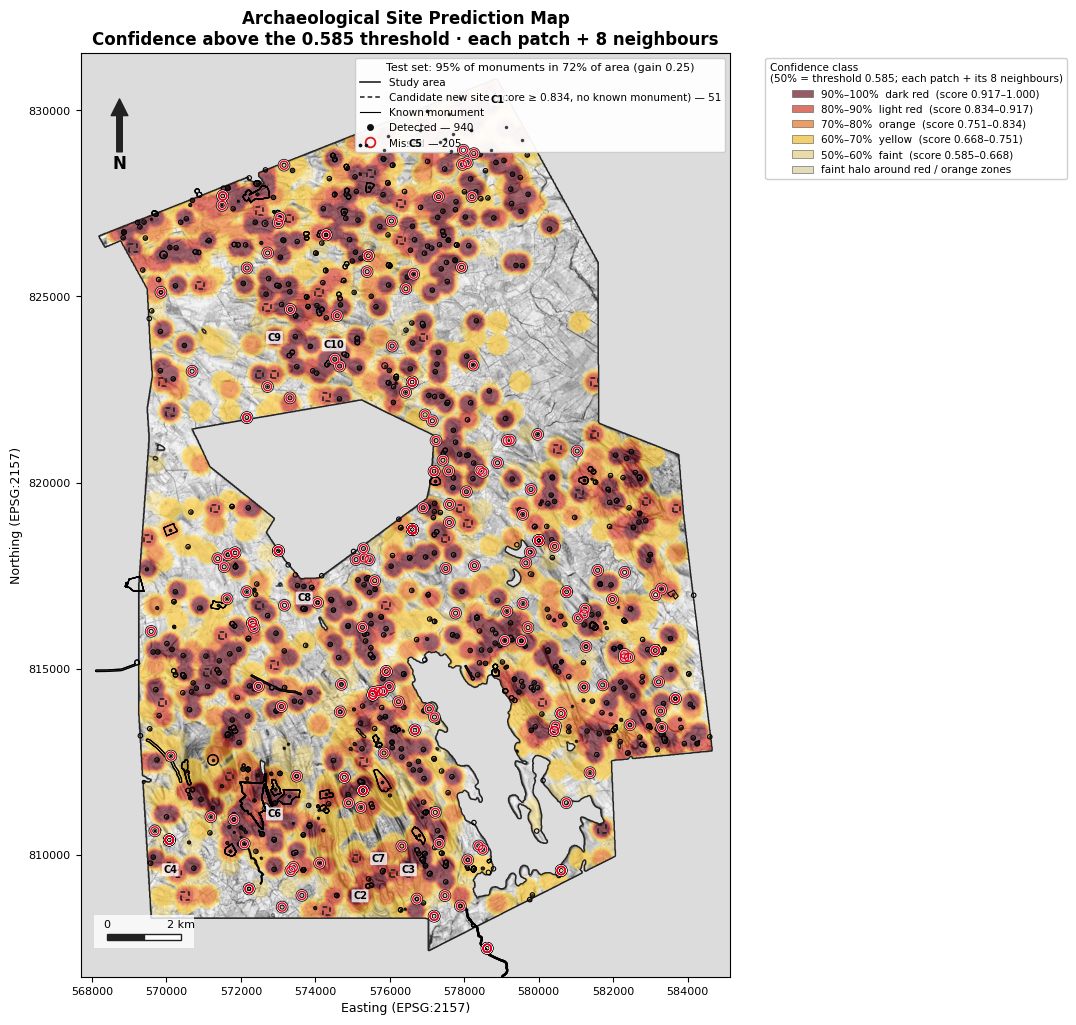

Saved: /kaggle/working/final_heatmap/prediction_map_v10.png


In [23]:
# ============================================================
# PREDICTION HEATMAP — v10
#   "Where are monuments likely to be?"  (the project's main result)
#   colour = model's CALIBRATED probability that a monument is there,
#            smoothed ~1 patch so neighbours share evidence
#   + known monuments on top (to check the map)
#   + candidate NEW sites (high probability, no recorded monument)
#   + accuracy on the TEST set (Kvamme's gain)
# Run AFTER "PREDICT + SPLIT MONUMENTS" (needs heatmap, monuments_detected,
# monuments_missed, MON_THRESHOLD). Run the 3D cell after this one to get
# the prediction map in 3D.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch, Rectangle, Patch
from matplotlib.path import Path as MplPath
from scipy import ndimage as ndi
from shapely.geometry import box as shapely_box, shape as shapely_shape
from shapely.ops import unary_union
import rasterio
from rasterio.features import shapes as rasterio_shapes, rasterize, geometry_mask
from rasterio.enums import Resampling, MergeAlg
from rasterio.transform import from_origin
from sklearn.linear_model import LogisticRegression

# ============================================================
# PARAMETERS
# ============================================================
STUDY_AREA_PATH = "/kaggle/input/datasets/shreyansdeshpande/svfblabla/finaldtm_SVF_R16_D16.tif"
MONUMENTS_PATH  = "/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg"

RESOLUTION_M = 20        # map grid
SMOOTH_M     = 150       # smoothing (≈ ¾ patch). 0 = raw patch squares, 250 = very soft
CALIBRATE    = True      # turn model scores into real probabilities (using validation patches)

P_LOW  = None            # below this probability: transparent (plain SVF).  None = average
                         #   chance of a patch holding a site (the "base rate")
P_HIGH = None            # at/above this: darkest red.  None = top 3 % of the area
HIGH_ZONE = None         # "high-probability zone" used for candidates + accuracy.
                         #   None = the model's validation-calibrated threshold

HAZE_ALPHA, CORE_ALPHA = 0.7, 0.58
SVF_LIGHTNESS = (0.18, 0.96)
SHOW_KNOWN    = True     # known monument outlines + detected/missed markers
SHOW_CANDIDATES = True   # dashed outlines around high-probability zones with no known monument
CANDIDATE_BUFFER_M = 100 # a zone counts as "new" if no known monument is within this distance
CANDIDATE_MIN_PATCHES = 2  # ignore isolated single high patches (usually noise)

# ---- NEIGHBOUR RULE (mentor's rule) -----------------------------------------
# Confidence classes run from the model's threshold (= "50 %") up to 1.0 (= "100 %"):
#     score = threshold + (class % − 50) / 50 × (1 − threshold)
#   e.g. threshold 0.585 → 50 % = 0.585 · 60 % = 0.668 · 70 % = 0.751 · 80 % = 0.834 · 90 % = 0.917
# Every patch in a class colours ITSELF and its 8 NEIGHBOURS in the class colour,
# with a soft fade around the outside.
NEIGHBOUR_RULE = True       # False = smooth probability map (previous v10 look)
RULE_USES      = "model"    # "model" = the model's own score · "calibrated" = calibrated probability
RULE_THRESHOLD = None       # None = the model's validation-calibrated threshold (bestthresh, e.g. 0.585)
SCALE_START    = 0.50       # the class % that equals the threshold (threshold = "50 %")
CLASSES = [                 # (class % from, colour value, name)
    (0.90, 1.00, "dark red"),
    (0.80, 0.80, "light red"),
    (0.70, 0.60, "orange"),
    (0.60, 0.24, "yellow"),
    (0.50, 0.08, "faint"),
]                           # below the last class (e.g. < 50 %) → not coloured
FADE_RING = True            # a faint halo one ring further out around red / orange classes
RULE_SHAPE    = "round"     # "round" = circular glow around each patch · "square" = 3×3 patch blocks
EDGE_SOFTEN_M = 30          # extra softening of the edges (0 = hard edges)

OUTPUT_DIR = Path("/kaggle/working/final_heatmap"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TITLE = "Archaeological Site Prediction Map"


# ============================================================
# 1. PATCH PROBABILITIES + CALIBRATION
# ============================================================
tiles = heatmap[["geometry", "probability", "filepath"]].copy()
fp = tiles["filepath"].str.replace("\\\\", "/", regex=True)
tiles["split"] = np.select([fp.str.contains("/train/"), fp.str.contains("/validation/"),
                            fp.str.contains("/test/")], ["train", "val", "test"], "other")
tiles["label"] = np.where(fp.str.contains("/no_site/"), 0, np.where(fp.str.contains("/site/"), 1, -1))

val = tiles[(tiles.split == "val") & (tiles.label >= 0)]
logit = lambda p: np.log(np.clip(p, 1e-4, 1 - 1e-4) / (1 - np.clip(p, 1e-4, 1 - 1e-4)))
base_rate = float(val.label.mean()) if len(val) else float((tiles.label == 1).mean())

if CALIBRATE and len(val) > 50 and val.label.nunique() == 2:
    platt = LogisticRegression(C=1e6).fit(logit(val.probability.values)[:, None], val.label.values)
    calib = lambda p: platt.predict_proba(logit(np.asarray(p, float))[:, None])[:, 1]
    tiles["p"] = calib(tiles.probability.values)
    print(f"Calibrated on {len(val):,} validation patches "
          f"(average model score {val.probability.mean():.2f} → real site rate {base_rate:.2f})")
else:
    calib = lambda p: np.asarray(p, float)
    tiles["p"] = tiles.probability
    print("Calibration skipped — using raw model scores")

thr_raw = float(globals().get("bestthresh", MON_THRESHOLD))
HIGH = float(HIGH_ZONE) if HIGH_ZONE else float(calib([thr_raw])[0])
print(f"High-probability zone: calibrated p ≥ {HIGH:.2f}  (model score ≥ {thr_raw:.3f})")


# ============================================================
# 2. SVF BASEMAP + STUDY AREA  (same handling as v9)
# ============================================================
with rasterio.open(STUDY_AREA_PATH) as src:
    rb, rh, rw = src.bounds, src.height, src.width
    dec = max(1, int(np.ceil(max(rh, rw) / 2500)))
    oh, ow = max(1, rh // dec), max(1, rw // dec)
    svf = src.read(1, out_shape=(oh, ow), resampling=Resampling.bilinear,
                   masked=True).astype(np.float32).filled(np.nan)
    valid = src.dataset_mask(out_shape=(oh, ow)) > 0
    raw = src.read(1, out_shape=(oh, ow), resampling=Resampling.nearest)
    t = src.transform * src.transform.scale(rw / ow, rh / oh)
    raster_crs = src.crs or "EPSG:2157"
edge = np.r_[raw[0], raw[-1], raw[:, 0], raw[:, -1]]; edge = edge[np.isfinite(edge)]
if edge.size:
    vals, cnts = np.unique(edge, return_counts=True)
    if cnts.max() > 0.5 * edge.size:
        filled = np.isclose(raw, vals[cnts.argmax()]) & valid
        if filled.mean() > 0.01:
            valid &= ~filled; svf[filled] = np.nan
valid = ndi.binary_closing(ndi.binary_opening(valid, iterations=1), iterations=2)
px_ = abs(t.a)
polys = [shapely_shape(g) for g, v in rasterio_shapes(valid.astype(np.uint8), transform=t) if v == 1]
polys = [p for p in polys if p.area > 0.05e6]
merged_geom = (unary_union(polys).buffer(px_).buffer(-px_).simplify(px_ / 2) if polys
               else shapely_box(rb.left, rb.bottom, rb.right, rb.top))
study_area = gpd.GeoSeries([merged_geom], crs=raster_crs).to_crs(tiles.crs)
merged_geom = study_area.iloc[0].buffer(0)
vv = svf[np.isfinite(svf)]
svf_vmin, svf_vmax = np.percentile(vv, 2), np.percentile(vv, 98)
svf_cmap = LinearSegmentedColormap.from_list("svf", [str(SVF_LIGHTNESS[0]), str(SVF_LIGHTNESS[1])])


# ============================================================
# 3. PROBABILITY SURFACE  (patches → grid → smooth)
# ============================================================
pad = max(3 * SMOOTH_M, 400)
minx, miny, maxx, maxy = study_area.total_bounds
minx -= pad; miny -= pad; maxx += pad; maxy += pad
nx = int(np.ceil((maxx - minx) / RESOLUTION_M)); ny = int(np.ceil((maxy - miny) / RESOLUTION_M))
x_edges = minx + np.arange(nx + 1) * RESOLUTION_M
y_edges = miny + np.arange(ny + 1) * RESOLUTION_M
gt = from_origin(minx, maxy, RESOLUTION_M, RESOLUTION_M)

psum = rasterize(zip(tiles.geometry, tiles.p), out_shape=(ny, nx), transform=gt,
                 fill=0, merge_alg=MergeAlg.add, dtype="float32")
pcnt = rasterize(((g, 1.0) for g in tiles.geometry), out_shape=(ny, nx), transform=gt,
                 fill=0, merge_alg=MergeAlg.add, dtype="float32")
psum, pcnt = np.flipud(psum), np.flipud(pcnt)          # → south-up like the other maps
covered = pcnt > 0
if SMOOTH_M > 0:                                        # normalised smoothing: no edge darkening
    s = SMOOTH_M / RESOLUTION_M
    num = ndi.gaussian_filter(np.where(covered, psum / np.maximum(pcnt, 1), 0), s)
    den = ndi.gaussian_filter(covered.astype("float32"), s)
    prob = np.where(den > 0.25, num / np.maximum(den, 1e-6), np.nan)
else:
    prob = np.where(covered, psum / np.maximum(pcnt, 1), np.nan)

in_area = np.flipud(~geometry_mask([merged_geom], out_shape=(ny, nx), transform=gt))
prob[~in_area] = np.nan
ok = np.isfinite(prob)
lo = float(P_LOW) if P_LOW is not None else base_rate
hi = float(P_HIGH) if P_HIGH is not None else float(np.percentile(prob[ok], 97))
hi = max(hi, lo + 0.05)
value = np.clip((np.nan_to_num(prob, nan=0) - lo) / (hi - lo), 0, 1)   # 0–1 colour value

tiles["p_rule"] = tiles["probability"] if RULE_USES == "model" else tiles["p"]
RULE_T = float(RULE_THRESHOLD) if RULE_THRESHOLD is not None else float(
    globals().get("bestthresh", globals().get("MON_THRESHOLD", 0.5)))
if RULE_USES == "calibrated":
    RULE_T = float(calib([RULE_T])[0])
to_score = lambda r_: RULE_T + (r_ - SCALE_START) / (1 - SCALE_START) * (1 - RULE_T)   # class % → score
to_class = lambda sc: SCALE_START + (sc - RULE_T) / (1 - RULE_T) * (1 - SCALE_START)   # score → class %
TIERS = [(to_score(r_), [c_, c_] + ([0.06] if FADE_RING and c_ >= 0.6 else []))
         for r_, c_, _ in CLASSES]
CLASS_EDGES = sorted([(to_score(r_), r_, c_, n_) for r_, c_, n_ in CLASSES], reverse=True)
if NEIGHBOUR_RULE:
    # patch size in grid cells (patches are ~200 m → 10 cells at 20 m)
    psize = float(np.median(np.sqrt(tiles.geometry.area)))
    k = max(1, int(round(psize / RESOLUTION_M)))
    rule = np.zeros((ny, nx), dtype="float32")
    tiers_sorted = sorted(TIERS, key=lambda t_: -t_[0])
    upper = np.inf
    print(f"\nNeighbour rule on the {'model score' if RULE_USES == 'model' else 'calibrated probability'} "
          f"(patch ≈ {psize:.0f} m):")
    print(f"  threshold = {RULE_T:.3f}  →  {SCALE_START:.0%} = score {RULE_T:.3f}, 100 % = score 1.000")
    for lo_t, levels in tiers_sorted:
        sel = tiles[(tiles.p_rule >= lo_t) & (tiles.p_rule < upper)]
        rel = to_class(lo_t)
        name = next(n_ for sc_, r_, c_, n_ in CLASS_EDGES if abs(sc_ - lo_t) < 1e-9)
        print(f"  {rel:.0%}–{min(to_class(upper), 1):.0%} "
              f"(score {lo_t:.3f}–{min(upper, 1):.3f}) → {name:9s}: {len(sel):,} patches")
        if len(sel):
            if RULE_SHAPE == "round":
                # distance (m) from every map cell to the nearest confident patch CENTRE
                cpts = sel.geometry.centroid
                cc = np.clip(((cpts.x - minx) / RESOLUTION_M).astype(int), 0, nx - 1)
                cr = np.clip(((cpts.y - miny) / RESOLUTION_M).astype(int), 0, ny - 1)
                seeds = np.ones((ny, nx), bool); seeds[cr, cc] = False
                dist = ndi.distance_transform_edt(seeds) * RESOLUTION_M
                # ring radii chosen so each circle covers the same area as the square rings
                # (patch ≈ radius 0.56·P, 3×3 block ≈ 1.7·P, 5×5 ≈ 2.8·P, 7×7 ≈ 3.9·P)
                radii = psize * np.array([0.56, 1.13, 1.69, 2.25])[:len(levels)]
                # colour stays at each ring's level inside its circle, then blends to the next
                xp = np.r_[0.0, np.repeat(radii, 2)[:-1] + np.tile([0, 0.35 * psize], len(radii))[:-1],
                           radii[-1] + 0.5 * psize]
                fp = np.r_[levels[0], np.repeat(levels, 2)[1:], 0.0]
                order = np.argsort(xp, kind="stable")
                glow = np.interp(dist, xp[order], fp[order]).astype("float32")
                rule = np.maximum(rule, glow)
            else:
                centre = np.flipud(rasterize(((g, 1) for g in sel.geometry), out_shape=(ny, nx),
                                             transform=gt, fill=0, dtype="uint8")) > 0
                for ring, level in enumerate(levels):
                    m = centre if ring == 0 else ndi.maximum_filter(centre.astype("uint8"),
                                                                    size=2 * ring * k + 1) > 0
                    rule = np.maximum(rule, np.where(m, level, 0).astype("float32"))
        upper = lo_t
    if EDGE_SOFTEN_M > 0:
        rule = ndi.gaussian_filter(rule, EDGE_SOFTEN_M / RESOLUTION_M)
    value = np.where(in_area, rule, 0)
    ok = in_area.copy()
print(f"Colour scale: transparent below {lo:.0%} (average chance), darkest red at ≥ {hi:.0%}")


# ============================================================
# 4. ACCURACY ON THE TEST SET  (Kvamme's gain)
# ============================================================
known = gpd.read_file(MONUMENTS_PATH) if Path(MONUMENTS_PATH).exists() else \
        gpd.GeoDataFrame(geometry=list(monuments_detected.geometry) + list(monuments_missed.geometry),
                         crs=monuments_detected.crs)
known = known.set_crs(tiles.crs) if known.crs is None else known.to_crs(tiles.crs)
known = known[known.geometry.notna() & ~known.geometry.is_empty].reset_index(drop=True)

cent = gpd.GeoDataFrame(geometry=known.geometry.representative_point(), crs=tiles.crs)
test_tiles = tiles[tiles.split == "test"]
test_mon = gpd.sjoin(cent, test_tiles[["geometry"]], how="inner", predicate="within")
test_mon = test_mon[~test_mon.index.duplicated()]
ci = np.clip(((test_mon.geometry.x - minx) / RESOLUTION_M).astype(int), 0, nx - 1)
ri = np.clip(((test_mon.geometry.y - miny) / RESOLUTION_M).astype(int), 0, ny - 1)
field = value if NEIGHBOUR_RULE else prob                  # the map actually drawn
site_p = field[ri, ci]; site_p = site_p[np.isfinite(site_p)]

def gain_row(name, level):
    area = float((field[ok] >= level).mean())
    sites = float((site_p >= level).mean()) if site_p.size else np.nan
    g = 1 - area / sites if sites and sites > 0 else np.nan
    return {"zone": name, "level ≥": round(level, 3), "% of area": round(100 * area, 1),
            "% of test monuments": round(100 * sites, 1), "Kvamme gain": round(g, 2)}

if NEIGHBOUR_RULE:
    rows, names_ = [], []
    for sc_, r_, c_, n_ in CLASS_EDGES:                     # cumulative: dark red, + light red, …
        names_.append(n_)
        rows.append(gain_row(" + ".join(names_) if len(names_) < 3 else f"{names_[0]} … {n_}",
                             c_ * 0.85))
else:
    rows = [gain_row("high-probability zone", HIGH)]
    for pct in (10, 20, 30):                                  # top X % of the area
        rows.append(gain_row(f"top {pct}% of area", float(np.percentile(prob[ok], 100 - pct))))
gain_table = pd.DataFrame(rows)
print(f"\nAccuracy on {len(site_p)} TEST monuments (never seen in training):")
print(gain_table.to_string(index=False))
print("Gain: 1 = perfect, 0 = no better than random, > 0.5 = useful predictive model")
gain_table.to_csv(OUTPUT_DIR / "prediction_map_accuracy.csv", index=False)


# ============================================================
# 5. CANDIDATE NEW SITES  (high probability, no known monument nearby)
# ============================================================
CAND_LEVEL = CLASS_EDGES[min(1, len(CLASS_EDGES) - 1)][0] if NEIGHBOUR_RULE else HIGH   # ≥ 80 % relative
CAND_COL = "p_rule" if NEIGHBOUR_RULE else "p"
CAND_MIN = 1 if NEIGHBOUR_RULE else CANDIDATE_MIN_PATCHES   # one ≥ 80 % patch is already strong
hi_tiles = tiles[tiles[CAND_COL] >= CAND_LEVEL]
near_known = gpd.sjoin(hi_tiles, gpd.GeoDataFrame(geometry=known.buffer(CANDIDATE_BUFFER_M),
                                                  crs=tiles.crs), how="inner", predicate="intersects")
cand_tiles = hi_tiles[~hi_tiles.index.isin(near_known.index)]
if len(cand_tiles):
    zones = gpd.GeoDataFrame(geometry=[cand_tiles.buffer(1).union_all() if hasattr(cand_tiles, "union_all")
                                       else cand_tiles.buffer(1).unary_union], crs=tiles.crs)
    zones = zones.explode(index_parts=False).reset_index(drop=True)
    zones["geometry"] = zones.buffer(-1)
    j = gpd.sjoin(cand_tiles[["geometry", CAND_COL]], zones.reset_index().rename(columns={"index": "zone_id"}),
                  how="inner", predicate="intersects")
    stats = j.groupby("zone_id")[CAND_COL].agg(["max", "mean", "count"])
    zones["max_p"] = stats["max"].round(3); zones["mean_p"] = stats["mean"].round(3)
    zones["n_patches"] = stats["count"]; zones["area_km2"] = (zones.area / 1e6).round(3)
    zones["score"] = (zones["n_patches"] * zones["mean_p"]).round(2)       # size × strength
    zones = zones[zones["n_patches"] >= CAND_MIN]
    zones = zones.sort_values("score", ascending=False).reset_index(drop=True)
    zones["candidate"] = [f"C{i + 1}" for i in range(len(zones))]
    zones.to_file(OUTPUT_DIR / "candidate_new_sites.gpkg", driver="GPKG")
    zc = zones.copy(); zc["easting"] = zc.centroid.x.round(0); zc["northing"] = zc.centroid.y.round(0)
    zc.drop(columns="geometry").to_csv(OUTPUT_DIR / "candidate_new_sites.csv", index=False)
    print(f"\nCandidate new sites: {len(zones)} zones of ≥ {CAND_MIN} patches "
          f"({int(zones.n_patches.sum()) if len(zones) else 0} patches, "
          f"{zones.area_km2.sum():.1f} km²) with p ≥ {CAND_LEVEL:.2f} and no known monument within "
          f"{CANDIDATE_BUFFER_M} m → candidate_new_sites.gpkg / .csv")
else:
    zones = gpd.GeoDataFrame(geometry=[], crs=tiles.crs)
    print("\nNo candidate new sites at this threshold.")


# ============================================================
# 6. COLOURS  (warm only)
# ============================================================
glow_cmap = LinearSegmentedColormap.from_list("warm", [
    (0.00, "#ffe97a"), (0.20, "#ffd23f"), (0.38, "#fdb030"), (0.55, "#fb8a24"),
    (0.70, "#f05a1e"), (0.83, "#d8261b"), (0.93, "#a80f16"), (1.00, "#650010")])
MIN_SHOW = 0.02
rgba = glow_cmap(value)
fade = np.clip((value - MIN_SHOW) / (0.12 - MIN_SHOW), 0, 1)
rgba[..., 3] = np.where(ok, fade * (HAZE_ALPHA + (CORE_ALPHA - HAZE_ALPHA) * value), 0)


# ============================================================
# 7. FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(11, 12))
fig.patch.set_facecolor("white"); ax.set_facecolor("#dcdcdc")
svf_img = ax.imshow(svf, extent=[rb.left, rb.right, rb.bottom, rb.top], origin="upper",
                    cmap=svf_cmap, vmin=svf_vmin, vmax=svf_vmax, interpolation="bilinear", zorder=0)
heat_img = ax.imshow(rgba, extent=[minx, maxx, miny, maxy], origin="lower",
                     interpolation="bilinear", zorder=1)
study_area.boundary.plot(ax=ax, color="#222", linewidth=1.0, zorder=3)

def _poly_path(geom):
    polys_ = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    verts, codes = [], []
    for p in polys_:
        for ring in [p.exterior, *p.interiors]:
            xy = np.asarray(ring.coords); verts.extend(xy)
            codes.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(xy) - 2) + [MplPath.CLOSEPOLY])
    return MplPath(verts, codes)
clip_patch = PathPatch(_poly_path(merged_geom), transform=ax.transData, facecolor="none", edgecolor="none")
ax.add_patch(clip_patch); heat_img.set_clip_path(clip_patch); svf_img.set_clip_path(clip_patch)

if SHOW_CANDIDATES and len(zones):
    zones.boundary.plot(ax=ax, color="#1a1a1a", linewidth=1.1, linestyle=(0, (3, 2)), zorder=4)
    for _, zr in zones.head(10).iterrows():                     # label the 10 strongest
        c = zr.geometry.representative_point()
        ax.text(c.x, c.y, zr.candidate, fontsize=7, fontweight="bold", ha="center", va="center",
                zorder=9, bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

if SHOW_KNOWN:
    kt = known.geom_type
    known[kt.isin(["Polygon", "MultiPolygon"])].boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)
    if kt.isin(["LineString", "MultiLineString"]).any():
        known[kt.isin(["LineString", "MultiLineString"])].plot(ax=ax, color="black", linewidth=1.1, zorder=5)
    dp = monuments_detected.geometry.centroid; mp = monuments_missed.geometry.centroid
    ax.scatter(dp.x, dp.y, s=6, c="#111", linewidths=0, alpha=0.8, zorder=6)
    ax.scatter(mp.x, mp.y, s=34, facecolors="none", edgecolors="#111", linewidths=3.2, zorder=7)
    ax.scatter(mp.x, mp.y, s=34, facecolors="none", edgecolors="white", linewidths=2.0, zorder=7)
    ax.scatter(mp.x, mp.y, s=34, facecolors="none", edgecolors="#e0001b", linewidths=1.0, zorder=8)

# colour bar in probability units, fading to grey at the low end like the map
t_ = np.linspace(0, 1, 256)
a_ = np.clip((t_ - MIN_SHOW) / (0.12 - MIN_SHOW), 0, 1) * (HAZE_ALPHA + (CORE_ALPHA - HAZE_ALPHA) * t_)
bar = glow_cmap(t_)[:, :3] * a_[:, None] + np.array([0.85, 0.85, 0.85]) * (1 - a_[:, None])
if not NEIGHBOUR_RULE:
    cbar = fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap=ListedColormap(bar)),
                        ax=ax, fraction=0.035, pad=0.02)
    ticks = np.linspace(0, 1, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"≤ {lo:.0%}"] + [f"{lo + v * (hi - lo):.0%}" for v in ticks[1:-1]] + [f"≥ {hi:.0%}"])
    cbar.set_label("Predicted probability of a monument" + (" (calibrated)" if CALIBRATE else ""), fontsize=9)
    cbar.ax.tick_params(labelsize=8)
else:
    # colour key for the neighbour rule (a separate legend box on the right)
    def _shown(level):                      # colour as it appears on the map (with its transparency)
        a = np.clip((level - MIN_SHOW) / (0.12 - MIN_SHOW), 0, 1) * (HAZE_ALPHA + (CORE_ALPHA - HAZE_ALPHA) * level)
        return tuple(np.array(glow_cmap(level)[:3]) * a + np.array([0.85, 0.85, 0.85]) * (1 - a))
    who = "model score" if RULE_USES == "model" else "calibrated probability"
    key = []
    up = None
    for sc_, r_, c_, n_ in CLASS_EDGES:
        rtxt = f"{r_:.0%}–{(up if up is not None else 1):.0%}"
        stxt = f"score {sc_:.3f}–{to_score(up) if up is not None else 1:.3f}"
        key.append(Patch(facecolor=_shown(c_), edgecolor="#555", linewidth=0.4,
                         label=f"{rtxt}  {n_}  ({stxt})"))
        up = r_
    if FADE_RING:
        key.append(Patch(facecolor=_shown(0.06), edgecolor="#555", linewidth=0.4,
                         label="faint halo around red / orange zones"))
    who = f"{SCALE_START:.0%} = threshold {RULE_T:.3f}; each patch + its 8 neighbours"
    fig.subplots_adjust(right=0.74)
    fig.legend(handles=key, loc="upper left", bbox_to_anchor=(0.755, 0.88), fontsize=7.5,
               title=f"Confidence class\n({who})", title_fontsize=7.5, frameon=True, framealpha=0.95)

hz = gain_table.iloc[-1] if NEIGHBOUR_RULE else gain_table.iloc[0]   # rule: all coloured classes
handles = [Line2D([0], [0], color="#222", lw=1.2, label="Study area")]
if SHOW_CANDIDATES and len(zones):
    handles.append(Line2D([0], [0], color="#1a1a1a", lw=1.1, linestyle=(0, (3, 2)),
                          label=f"Candidate new site (score ≥ {CAND_LEVEL:.3f}, no known monument) — {len(zones)}"))
if SHOW_KNOWN:
    handles += [Line2D([0], [0], color="black", lw=0.8, label="Known monument"),
                Line2D([0], [0], marker="o", color="none", markerfacecolor="#111", markeredgecolor="none",
                       markersize=5, label=f"Detected — {len(monuments_detected)}"),
                Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="#d7191c",
                       markeredgewidth=1.3, markersize=7, label=f"Missed — {len(monuments_missed)}")]
ax.legend(handles=handles, loc="upper right", fontsize=7.5, framealpha=0.95,
          title=(f"Test set: {hz['% of test monuments']:.0f}% of monuments in "
                 f"{hz['% of area']:.0f}% of area (gain {hz['Kvamme gain']:.2f})"), title_fontsize=8)

sxmin, symin, sxmax, symax = study_area.total_bounds
pxm, pym = 0.03 * (sxmax - sxmin), 0.03 * (symax - symin)
ax.set_xlim(sxmin - pxm, sxmax + pxm); ax.set_ylim(symin - pym, symax + pym); ax.set_aspect("equal")
x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim(); span = x1 - x0
barlen = [1000, 2000, 5000, 10000][int(np.argmin(np.abs(np.array([1000, 2000, 5000, 10000]) - span / 5)))]
bx, by, bh = x0 + 0.04 * span, y0 + 0.04 * (y1 - y0), 0.006 * (y1 - y0)
ax.add_patch(Rectangle((bx - 0.02 * span, by - 1.5 * bh), barlen + 0.04 * span, 6 * bh,
                       facecolor="white", edgecolor="none", alpha=0.8, zorder=6.5))
ax.add_patch(Rectangle((bx, by), barlen / 2, bh, facecolor="#222", edgecolor="#222", zorder=7))
ax.add_patch(Rectangle((bx + barlen / 2, by), barlen / 2, bh, facecolor="white", edgecolor="#222", zorder=7))
ax.text(bx, by + 2.2 * bh, "0", ha="center", fontsize=8, zorder=7)
ax.text(bx + barlen, by + 2.2 * bh, f"{barlen / 1000:g} km", ha="center", fontsize=8, zorder=7)
ax.annotate("N", xy=(x0 + 0.06 * span, y1 - 0.05 * (y1 - y0)), xytext=(x0 + 0.06 * span, y1 - 0.12 * (y1 - y0)),
            ha="center", va="center", fontsize=12, fontweight="bold", zorder=7,
            arrowprops=dict(facecolor="#222", edgecolor="#222", width=4, headwidth=12))
ax.set_title(f"{TITLE}\n" + (f"Confidence above the {RULE_T:.3f} threshold · each patch + 8 neighbours"
                              if NEIGHBOUR_RULE else
                              f"ConvNeXt-Tiny prediction over Sky-View Factor (smoothed {SMOOTH_M} m)"),
             fontsize=12, fontweight="bold")
ax.set_xlabel("Easting (EPSG:2157)", fontsize=9); ax.set_ylabel("Northing (EPSG:2157)", fontsize=9)
ax.tick_params(labelsize=8); ax.ticklabel_format(style="plain", useOffset=False)
if not NEIGHBOUR_RULE:
    plt.tight_layout()
png_path = OUTPUT_DIR / "prediction_map_v10.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {png_path}")


# ============================================================
# 8. HAND OVER TO THE 3D CELL  (3D will now show this prediction surface)
# ============================================================
if NEIGHBOUR_RULE:
    density_km2 = value.astype("float32")                 # the rule's 0–1 colour value
    MAP_CBAR_LABEL = f"Confidence above threshold {RULE_T:.3f}"
    MAP_TICKTEXT = [f"{SCALE_START:.0%} (score {RULE_T:.2f})", "70 %", "90–100 %"]
else:
    density_km2 = np.clip((np.nan_to_num(prob, nan=0) - lo) / (hi - lo), 0, None).astype("float32")
    # (not capped at 1 → the strongest areas still rise above the rest in 3D)
    MAP_CBAR_LABEL = "Predicted probability of a monument"
    MAP_TICKTEXT = [f"≤ {lo:.0%}", f"{(lo + hi) / 2:.0%}", f"≥ {hi:.0%}"]
vmax, GAMMA = 1.0, 1.0
MAP_SUBTITLE = "Height & colour = predicted probability of a monument  ·  ground = DTM with Sky-View Factor shading"

DTM files: 1
Area: 18.0 × 26.0 km  →  grid 700 × 485 at 37 m
Elevation: 5.7 – 354.6 m  (relief 348.9 m)
Vertical exaggeration: ×8.9  (auto; ×1 would look almost flat for 349 m of relief over 26 km)


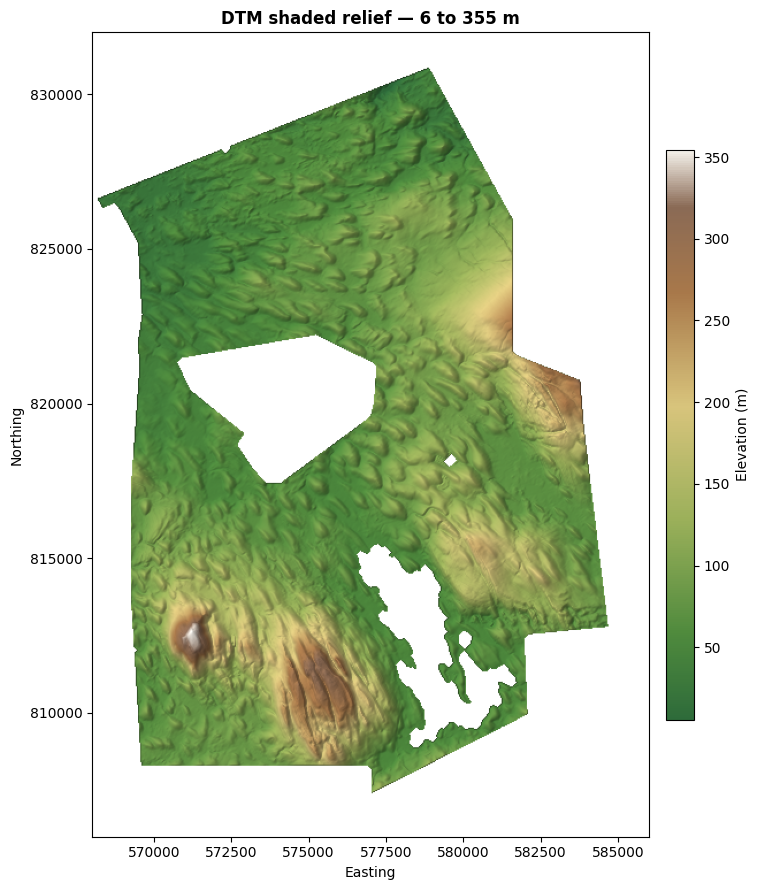

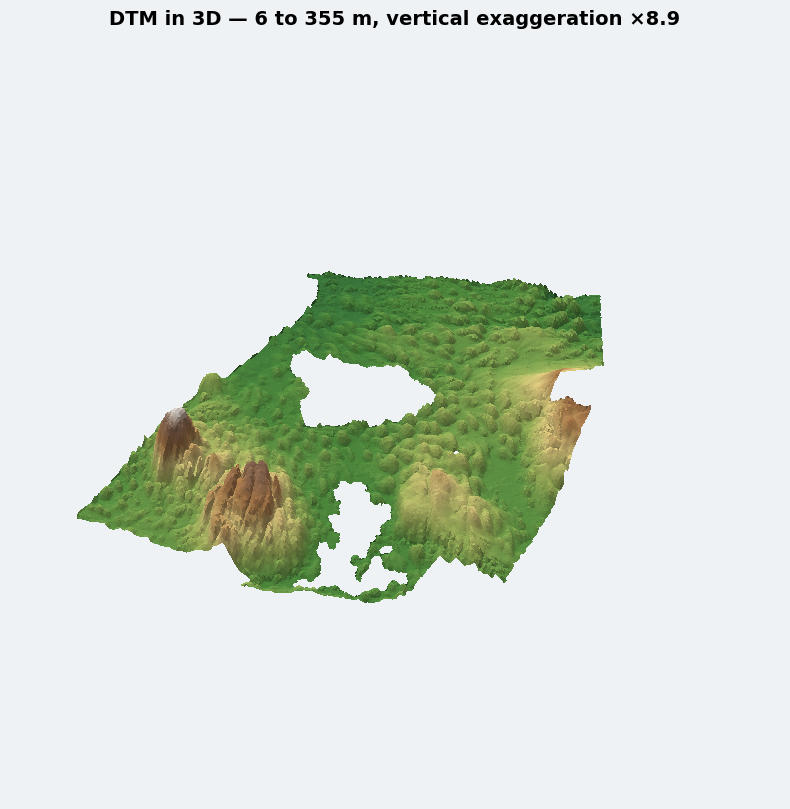

Saved to /kaggle/working/dtm_3d: dtm_shaded_relief.png, dtm_3d.png, dtm_3d_interactive.html


In [24]:
# ============================================================
# DTM 3D VIEWER — stand-alone (needs nothing from other cells)
#   Reads your DTM (one file or a folder of tiles), then shows:
#     1. an interactive 3D terrain you can rotate / zoom (Plotly)
#     2. a high-resolution 3D image (matplotlib, hillshaded)
#     3. a 2D shaded-relief map for reference
# ============================================================

from pathlib import Path
import numpy as np
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import transform_bounds
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap
import plotly.graph_objects as go

# ============================================================
# PARAMETERS
# ============================================================
DTM_PATH   = Path("/kaggle/input/datasets/shreyansdeshpande/dtmfile1234")   # file OR folder of tiles
MAX_PIXELS = 700          # longest side of the 3D grid (500–900). Bigger = more detail, slower
VERT_EXAG  = "auto"       # "auto" = hills clearly visible · 1 = true scale · e.g. 3, 5, 10
AUTO_RELIEF_SHARE = 0.12  # "auto": tallest relief drawn as ~12 % of the map width
COLORS     = "terrain"    # "terrain" (green → brown → white) or "earth" (muted, realistic)
VIEW_ELEV, VIEW_AZIM = 35, -60     # static image camera
OUTPUT_DIR = Path("/kaggle/working/dtm_3d"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. FIND FILES + COMMON GRID
# ============================================================
if DTM_PATH.is_file():
    files = [DTM_PATH]
else:
    files = sorted({p for e in ("*.tif", "*.tiff", "*.TIF", "*.vrt", "*.img") for p in DTM_PATH.rglob(e)})
if not files:
    raise FileNotFoundError(f"No DTM rasters found in {DTM_PATH}")
print(f"DTM files: {len(files)}")

with rasterio.open(files[0]) as s0:
    crs = s0.crs
bounds = []
for f in files:
    with rasterio.open(f) as s:
        bounds.append(transform_bounds(s.crs, crs, *s.bounds) if s.crs != crs else tuple(s.bounds))
bx0 = min(b[0] for b in bounds); by0 = min(b[1] for b in bounds)
bx1 = max(b[2] for b in bounds); by1 = max(b[3] for b in bounds)
res = max(bx1 - bx0, by1 - by0) / MAX_PIXELS
nx, ny = int(np.ceil((bx1 - bx0) / res)), int(np.ceil((by1 - by0) / res))
grid_t = from_origin(bx0, by1, res, res)
print(f"Area: {(bx1 - bx0) / 1000:.1f} × {(by1 - by0) / 1000:.1f} km  →  grid {ny} × {nx} at {res:.0f} m")


# ============================================================
# 2. READ + MOSAIC  (handles 'no data' and constant fill values)
# ============================================================
acc = np.zeros((ny, nx)); cnt = np.zeros((ny, nx))
for f in files:
    with rasterio.open(f) as src:
        nod = src.nodata
        if nod is None:          # no nodata set → look for a constant fill along the raster edge
            sm = src.read(1, out_shape=(max(1, src.height // 20), max(1, src.width // 20)),
                          resampling=Resampling.nearest)
            e = np.r_[sm[0], sm[-1], sm[:, 0], sm[:, -1]]
            v, c = np.unique(e, return_counts=True)
            nod = float(v[c.argmax()]) if c.max() > 0.5 * e.size else -9999
        with WarpedVRT(src, crs=crs, transform=grid_t, width=nx, height=ny,
                       resampling=Resampling.average, src_nodata=nod,
                       nodata=np.nan, dtype="float32") as vrt:
            a = vrt.read(1).astype("float64")
    a[(a < -500) | (a > 9000)] = np.nan
    ok = np.isfinite(a); acc[ok] += a[ok]; cnt[ok] += 1
dem = np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan)          # north-up
valid = np.isfinite(dem)
# fill tiny holes so the surface is continuous (big empty areas stay empty)
holes, n_h = ndi.label(~valid)
if n_h:
    sizes = ndi.sum(np.ones_like(holes), holes, range(1, n_h + 1))
    edge_lbl = set(np.unique(np.r_[holes[0], holes[-1], holes[:, 0], holes[:, -1]]))
    small = np.isin(holes, [i + 1 for i, s in enumerate(sizes) if s < 50 and (i + 1) not in edge_lbl])
    small |= ndi.binary_closing(valid, iterations=3) & ~valid        # thin seams between tiles
    if small.any():
        w = ndi.gaussian_filter(valid.astype(float), 2); vv = ndi.gaussian_filter(np.nan_to_num(dem), 2)
        dem[small] = (vv / np.maximum(w, 1e-6))[small]; valid |= small

zmin, zmax = np.nanmin(dem), np.nanmax(dem)
relief = zmax - zmin
print(f"Elevation: {zmin:.1f} – {zmax:.1f} m  (relief {relief:.1f} m)")


# ============================================================
# 3. VERTICAL EXAGGERATION
# ============================================================
width_m = max(nx, ny) * res
exag = (AUTO_RELIEF_SHARE * width_m / max(relief, 1)) if VERT_EXAG == "auto" else float(VERT_EXAG)
exag = float(np.clip(exag, 1, 60))
print(f"Vertical exaggeration: ×{exag:.1f}  "
      f"({'auto' if VERT_EXAG == 'auto' else 'fixed'}; ×1 would look almost flat for {relief:.0f} m of relief "
      f"over {width_m / 1000:.0f} km)")


# ============================================================
# 4. COLOURS  (elevation tint × multi-direction hillshade)
# ============================================================
if COLORS == "earth":
    cmap = LinearSegmentedColormap.from_list("earth", [
        "#4f6b3a", "#6f8a4a", "#98a060", "#b9ae7a", "#c9b48f", "#d9cbb0", "#efe9df"])
else:
    cmap = LinearSegmentedColormap.from_list("terrain_nice", [
        (0.00, "#2e6b3a"), (0.15, "#4f8a3d"), (0.35, "#9bb05a"), (0.55, "#d8c47c"),
        (0.75, "#a8784a"), (0.90, "#8a6a55"), (1.00, "#f4f1ea")])

dem_f = np.where(valid, dem, np.nanmedian(dem))
ls_list = [(315, 0.45), (270, 0.2), (0, 0.2), (225, 0.15)]
hs = sum(wt * LightSource(azdeg=az, altdeg=40).hillshade(dem_f, vert_exag=exag, dx=res, dy=res)
         for az, wt in ls_list)
elev_n = np.clip((dem_f - zmin) / max(relief, 1e-6), 0, 1)
rgb = cmap(elev_n)[..., :3] * (0.35 + 0.8 * hs[..., None])
rgb = np.clip(rgb, 0, 1)

xs = bx0 + (np.arange(nx) + 0.5) * res
ys = by1 - (np.arange(ny) + 0.5) * res                       # north-up rows
Z = np.where(valid, (dem - zmin) * exag, np.nan)


# ============================================================
# 5. 2D SHADED RELIEF (reference)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(9, 9))
ax2.imshow(np.dstack([rgb, valid.astype(float)]), extent=[bx0, bx0 + nx * res, by1 - ny * res, by1])
ax2.set_title(f"DTM shaded relief — {zmin:.0f} to {zmax:.0f} m", fontweight="bold")
ax2.set_xlabel("Easting"); ax2.set_ylabel("Northing"); ax2.ticklabel_format(style="plain", useOffset=False)
sm_ = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(zmin, zmax))
fig2.colorbar(sm_, ax=ax2, fraction=0.035, pad=0.02, label="Elevation (m)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "dtm_shaded_relief.png", dpi=250, bbox_inches="tight"); plt.show()


# ============================================================
# 6. INTERACTIVE 3D  (Plotly — rotate / zoom / hover shows real elevation)
# ============================================================
step = max(1, int(np.ceil(max(nx, ny) / 450)))              # keep the browser responsive
Zs = Z[::step, ::step]; Es = np.where(valid, dem, np.nan)[::step, ::step]
fig3 = go.Figure(go.Surface(
    x=xs[::step], y=ys[::step], z=Zs, surfacecolor=Es,
    colorscale=[[t, "#%02x%02x%02x" % tuple(int(255 * c) for c in cmap(t)[:3])] for t in np.linspace(0, 1, 11)],
    cmin=zmin, cmax=zmax, colorbar=dict(title=dict(text="Elevation (m)", side="right"), len=0.6),
    lighting=dict(ambient=0.45, diffuse=0.85, specular=0.08, roughness=0.9, fresnel=0.1),
    lightposition=dict(x=-5e4, y=5e4, z=4e4),
    customdata=Es, hovertemplate="E %{x:.0f}<br>N %{y:.0f}<br>elevation %{customdata:.1f} m<extra></extra>"))
span_x, span_y = nx * res, ny * res
fig3.update_layout(
    title=f"DTM in 3D (vertical exaggeration ×{exag:.1f})", width=1150, height=820,
    margin=dict(l=0, r=0, t=50, b=0), paper_bgcolor="#e9eef2",
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
               bgcolor="#e9eef2", aspectmode="manual",
               aspectratio=dict(x=span_x / max(span_x, span_y), y=span_y / max(span_x, span_y),
                                z=float(np.nanmax(Zs)) / max(span_x, span_y)),
               camera=dict(eye=dict(x=0.9, y=-1.4, z=0.9))))
fig3.write_html(OUTPUT_DIR / "dtm_3d_interactive.html", include_plotlyjs=True)
fig3.show()


# ============================================================
# 7. HIGH-RESOLUTION 3D IMAGE  (matplotlib)
# ============================================================
st2 = max(1, int(np.ceil(max(nx, ny) / 600)))
Xg, Yg = np.meshgrid(xs[::st2], ys[::st2])
Zg = Z[::st2, ::st2]
fc = np.dstack([rgb[::st2, ::st2], valid[::st2, ::st2].astype(float)])
fig = plt.figure(figsize=(14, 10), facecolor="#eef2f5")
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
ax.set_facecolor("#eef2f5")
ax.plot_surface(Xg, Yg, np.where(np.isfinite(Zg), Zg, np.nan), facecolors=fc,
                rstride=1, cstride=1, linewidth=0, antialiased=False, shade=False)
ax.set_box_aspect((span_x, span_y, float(np.nanmax(Zg))), zoom=1.25)
ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
ax.set_axis_off()
ax.set_title(f"DTM in 3D — {zmin:.0f} to {zmax:.0f} m, vertical exaggeration ×{exag:.1f}",
             fontsize=14, fontweight="bold", pad=0)
plt.savefig(OUTPUT_DIR / "dtm_3d.png", dpi=250, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved to {OUTPUT_DIR}: dtm_shaded_relief.png, dtm_3d.png, dtm_3d_interactive.html")

In [25]:
# ============================================================
# WEB EXPORT — 2D heatmap + 3D terrain (no 3D heatmap)
# Run AFTER v10 (for 2D) and/or the DTM cell (for 3D).
# Produces: /kaggle/working/web_export/web_export.zip
# ============================================================

import json, zipfile, shutil
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from PIL import Image
from rasterio.warp import transform_bounds

WGS84 = "EPSG:4326"

# ---- dedicated output dir: no clash with v10's or DTM's OUTPUT_DIR ----
WEB_EXPORT_DIR = Path("/kaggle/working/web_export")
WEB_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

tmp = WEB_EXPORT_DIR / "_tmp"
if tmp.exists(): shutil.rmtree(tmp)
tmp.mkdir(parents=True, exist_ok=True)

# ---- sanity: which upstream cells' outputs are present? ----
have_v10 = all(n in globals() for n in
               ["tiles", "rgba", "minx", "miny", "maxx", "maxy"])
have_dtm = all(n in globals() for n in
               ["rgb", "valid", "bx0", "by0", "bx1", "by1", "res",
                "crs", "dem", "zmin", "zmax", "exag"])
print(f"v10 outputs in memory:  {'✅' if have_v10 else '❌'}")
print(f"DTM outputs in memory:  {'✅' if have_dtm else '❌'}")
assert have_v10 or have_dtm, "Nothing to export — run v10 and/or the DTM cell first."

# ============================================================
# PART A — 2D HEATMAP
# ============================================================
has_candidates = False
overlay_bounds_wgs = None
terrain_meta = None

if have_v10:
    tiles_crs = tiles.crs

    MAX_PNG_SIDE = 2048
    step_png = max(1, int(np.ceil(max(rgba.shape[0], rgba.shape[1]) / MAX_PNG_SIDE)))
    rgba_small = rgba[::step_png, ::step_png]
    Image.fromarray((np.clip(rgba_small, 0, 1) * 255).astype("uint8"), "RGBA") \
         .save(tmp / "heatmap_overlay.png", optimize=True)

    overlay_bounds_wgs = list(transform_bounds(tiles_crs, WGS84,
                                               minx, miny, maxx, maxy))

    patch_cols = [c for c in ["geometry", "probability", "p", "p_rule", "split", "label"]
                  if c in tiles.columns]
    patches = tiles[patch_cols].to_crs(WGS84).copy()
    patches = patches.rename(columns={"probability": "score", "p": "prob_calibrated"})
    patches.to_file(tmp / "patches.geojson", driver="GeoJSON")

    det = monuments_detected[["geometry"]].copy(); det["status"] = "detected"
    mis = monuments_missed[["geometry"]].copy();    mis["status"] = "missed"
    mon_all = pd.concat([det, mis], ignore_index=True)
    mon_all = gpd.GeoDataFrame(mon_all, geometry="geometry",
                               crs=monuments_detected.crs).to_crs(WGS84)
    mon_all["id"] = [f"M{i+1:04d}" for i in range(len(mon_all))]
    mon_all.to_file(tmp / "monuments.geojson", driver="GeoJSON")

    study_area.to_crs(WGS84).to_file(tmp / "study_area.geojson", driver="GeoJSON")

    has_candidates = "zones" in globals() and len(zones) > 0
    if has_candidates:
        zones.to_crs(WGS84).to_file(tmp / "candidate_sites.geojson", driver="GeoJSON")

    print(f"2D heatmap export ready  ({rgba_small.shape[1]}×{rgba_small.shape[0]} px)")

# ============================================================
# PART B — 3D TERRAIN
# ============================================================
if have_dtm:
    MAX_TERRAIN_SIDE = 2048
    step_t = max(1, int(np.ceil(max(rgb.shape[0], rgb.shape[1]) / MAX_TERRAIN_SIDE)))
    rgb_small = np.clip(rgb[::step_t, ::step_t], 0, 1)
    valid_small = valid[::step_t, ::step_t]
    rgba_terrain = np.dstack([rgb_small, valid_small.astype(float)])
    Image.fromarray((rgba_terrain * 255).astype("uint8"), "RGBA") \
         .save(tmp / "terrain_texture.png", optimize=True)

    MAX_GRID_SIDE = 1024
    step_g = max(1, int(np.ceil(max(dem.shape[0], dem.shape[1]) / MAX_GRID_SIDE)))
    dem_small = dem[::step_g, ::step_g]
    np.save(tmp / "terrain_grid.npy", dem_small.astype("float32"))

    terrain_meta = {
        "grid_file": "terrain_grid.npy",
        "texture_file": "terrain_texture.png",
        "shape": list(dem_small.shape),
        "resolution_m": float(res * step_g),
        "bounds_wgs84": list(transform_bounds(crs, WGS84, bx0, by0, bx1, by1)),
        "elevation_min_m": float(zmin),
        "elevation_max_m": float(zmax),
        "relief_m": float(zmax - zmin),
        "vertical_exaggeration": float(exag),
        "crs_projected": str(crs),
    }
    (tmp / "terrain_meta.json").write_text(json.dumps(terrain_meta, indent=2), encoding="utf-8")

    print(f"3D terrain export ready  ({dem_small.shape[1]}×{dem_small.shape[0]} grid, "
          f"relief {zmax-zmin:.0f} m, ×{exag:.1f} exaggeration)")

# ============================================================
# PART C — settings.json
# ============================================================
settings = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "views": [],
    "thresholds": {},
    "colormap": {},
    "confidence_classes": [],
    "counts": {},
}

if have_v10:
    settings["thresholds"] = {
        "rule_threshold": float(RULE_T),
        "mon_threshold":  float(MON_THRESHOLD),
        "bestthresh":     float(globals().get("bestthresh", MON_THRESHOLD)),
    }
    settings["colormap"] = {
        "name": "warm",
        "stops": [
            [0.00, "#ffe97a"], [0.20, "#ffd23f"], [0.38, "#fdb030"],
            [0.55, "#fb8a24"], [0.70, "#f05a1e"], [0.83, "#d8261b"],
            [0.93, "#a80f16"], [1.00, "#650010"],
        ],
        "label": "Predicted probability of a monument"
                 + (" (calibrated)" if CALIBRATE else ""),
    }
    settings["confidence_classes"] = [
        {"label": n_, "class_pct": float(r_), "score": float(sc_), "color_value": float(c_)}
        for sc_, r_, c_, n_ in CLASS_EDGES
    ] if NEIGHBOUR_RULE else []
    settings["counts"] = {
        "detected":   int(len(monuments_detected)),
        "missed":     int(len(monuments_missed)),
        "patches":    int(len(tiles)),
        "recall":     float(len(monuments_detected) /
                            max(len(monuments_detected) + len(monuments_missed), 1)),
        "candidates": int(len(zones)) if has_candidates else 0,
    }
    settings["views"].append({
        "id": "heatmap",
        "label": "Prediction map (2D)",
        "kind": "map2d",
        "crs_projected": str(tiles_crs),
        "crs_web": WGS84,
        "center_bounds_wgs84": overlay_bounds_wgs,
        "layers": [
            {"id": "svf",       "file": Path(globals().get(
                "STUDY_AREA_PATH",
                "/kaggle/input/datasets/shreyansdeshpande/svfblabla/finaldtm_SVF_R16_D16.tif"
            )).name, "type": "raster",
             "label": "Sky-View Factor basemap", "default_on": True},
            {"id": "heatmap",   "file": "heatmap_overlay.png", "type": "raster-overlay",
             "label": "Prediction heatmap", "default_on": True,
             "bounds_wgs84": overlay_bounds_wgs},
            {"id": "study",     "file": "study_area.geojson",  "type": "outline",
             "label": "Study area", "default_on": True, "color": "#222222"},
            {"id": "monuments", "file": "monuments.geojson",   "type": "points",
             "label": "Monuments", "default_on": True},
            {"id": "patches",   "file": "patches.geojson",     "type": "polygons",
             "label": "Model patches", "default_on": False},
            *([{"id": "candidates", "file": "candidate_sites.geojson", "type": "polygons",
                "label": "Candidate new sites", "default_on": True, "dashed": True}]
              if has_candidates else []),
        ],
    })

if have_dtm:
    settings["views"].append({
        "id": "terrain",
        "label": "DTM terrain (3D)",
        "kind": "terrain3d",
        "texture_file": "terrain_texture.png",
        "grid_file":    "terrain_grid.npy",
        "meta_file":    "terrain_meta.json",
        "bounds_wgs84": terrain_meta["bounds_wgs84"],
        "elevation_min_m": terrain_meta["elevation_min_m"],
        "elevation_max_m": terrain_meta["elevation_max_m"],
        "relief_m":        terrain_meta["relief_m"],
        "vertical_exaggeration": terrain_meta["vertical_exaggeration"],
        "resolution_m":    terrain_meta["resolution_m"],
    })

(tmp / "settings.json").write_text(json.dumps(settings, indent=2), encoding="utf-8")

# ============================================================
# PART D — zip
# ============================================================
zip_path = WEB_EXPORT_DIR / "web_export.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=9) as z:
    for f in sorted(tmp.iterdir()):
        z.write(f, f.name)
    # include SVF for the 2D basemap (with safe fallback)
    svf_src = Path(globals().get(
        "STUDY_AREA_PATH",
        "/kaggle/input/datasets/shreyansdeshpande/svfblabla/finaldtm_SVF_R16_D16.tif"
    ))
    if svf_src.exists():
        z.write(svf_src, svf_src.name)
    else:
        print(f"⚠ SVF not found at {svf_src} — zip will have no basemap")

shutil.rmtree(tmp, ignore_errors=True)

print(f"\n✅ web_export.zip  →  {zip_path}  ({zip_path.stat().st_size / 1e6:.1f} MB)")
with zipfile.ZipFile(zip_path) as z:
    for info in z.infolist():
        print(f"   {info.filename:<28}  {info.file_size/1e6:6.2f} MB")
print("\n   Download: Kaggle → Output → web_export → web_export.zip")
print("   Unzip into  backend/data/")

v10 outputs in memory:  ✅
DTM outputs in memory:  ✅
2D heatmap export ready  (869×1216 px)
3D terrain export ready  (485×700 grid, relief 349 m, ×8.9 exaggeration)

✅ web_export.zip  →  /kaggle/working/web_export/web_export.zip  (799.8 MB)
   candidate_sites.geojson         0.04 MB
   heatmap_overlay.png             0.65 MB
   monuments.geojson               3.28 MB
   patches.geojson                 2.49 MB
   settings.json                   0.00 MB
   study_area.geojson              0.14 MB
   terrain_grid.npy                1.36 MB
   terrain_meta.json               0.00 MB
   terrain_texture.png             0.32 MB
   finaldtm_SVF_R16_D16.tif      1872.03 MB

   Download: Kaggle → Output → web_export → web_export.zip
   Unzip into  backend/data/


In [26]:
import shutil, json, pickle
from pathlib import Path
SAVE = Path("/kaggle/working/final_state")
SAVE.mkdir(parents=True, exist_ok=True)

# Model
shutil.copy(ckptpath, SAVE / "model.pth")

# LiDAR stats
np.savez(SAVE / "lidar_stats.npz", mean=LIDARMEAN, std=LIDARSTD)

# Heatmap + monuments (from PREDICT cell)
heatmap.to_file(SAVE / "heatmap_tiles.gpkg", driver="GPKG")
monuments_detected.to_file(SAVE / "monuments_detected.gpkg", driver="GPKG")
monuments_missed.to_file(SAVE / "monuments_missed.gpkg", driver="GPKG")

# Settings
json.dump({"bestthresh": float(bestthresh),
           "MON_THRESHOLD": float(MON_THRESHOLD)},
          open(SAVE / "settings.json", "w"))

# Optional: cache the raw patches too, so you never re-read .tif files
with open(SAVE / "cache_train.pkl", "wb") as f: pickle.dump(traincache, f)
with open(SAVE / "cache_val.pkl",   "wb") as f: pickle.dump(valcache,   f)
with open(SAVE / "cache_test.pkl",  "wb") as f: pickle.dump(testcache,  f)

print("Saved:")
for f in sorted(SAVE.iterdir()):
    print(" ", f.name, f.stat().st_size // 1024 // 1024, "MB")

Saved:
  cache_test.pkl 1473 MB
  cache_train.pkl 6035 MB
  cache_val.pkl 2089 MB
  heatmap_tiles.gpkg 1 MB
  lidar_stats.npz 0 MB
  model.pth 106 MB
  monuments_detected.gpkg 2 MB
  monuments_missed.gpkg 0 MB
  settings.json 0 MB
